In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [3]:
data = processed_data_20cm

In [21]:
freqs = list(data.keys())
volts = []

for i in range(len(freqs)):
    volts.append(list(data[freqs[i]].keys()))

In [41]:
# Trying out a naive variance-comparison
print("Comparing variances of P0 and P3 for f = 1.4 Hz, A = 0.3 V, D = 20 cm, with plates")
print()
eta_P0_r1 = data[1.4][0.3]['p005']["R1"]['P_0'].dropna().values
eta_P3_r1 = data[1.4][0.3]['p005']["R1"]['P_3'].dropna().values

# Sample variances
var_P0 = np.var(eta_P0_r1, ddof=1)
var_P3 = np.var(eta_P3_r1, ddof=1)

# Classical F-test statistic
F_statistic = var_P0 / var_P3

print(f"Variance of P0: {var_P0:.4e}")
print(f"Variance of P3: {var_P3:.4e}")

N0 = len(eta_P0_r1)
N3 = len(eta_P3_r1)
df1 = N0 - 1  # numerator df (P_0)
df2 = N3 - 1  # denominator df (P_3)
print(f'Number of samples in P0: {df1}, P3: {df2}')
print()
from scipy.stats import f

alpha = 0.05  # significance level

# Critical values (two-sided test)
F_crit_low  = f.ppf(alpha / 2, df1, df2)
F_crit_high = f.ppf(1 - alpha / 2, df1, df2)

print(f"Critical F values for alpha={alpha}:")
print("F critical low:", F_crit_low)
print("F critical high:", F_crit_high)

# p-value for two-sided test
if F_statistic >= 1:
    p_value = 2 * (1 - f.cdf(F_statistic, df1, df2))
else:
    p_value = 2 * f.cdf(F_statistic, df1, df2)

print("F statistic:", F_statistic)
print("p-value:", p_value)

# Conclusion
if p_value < alpha:
    print("Reject the null hypothesis: variances are significantly different.")
else:    print("Fail to reject the null hypothesis: no significant difference in variances.")


print("\nNow adjusting for autocorrelation using effective degrees of freedom...")
print()
import numpy as np

def lag1_autocorr(x):
    x = x - np.mean(x)
    return np.corrcoef(x[:-1], x[1:])[0, 1]

r0 = lag1_autocorr(eta_P0_r1)
r3 = lag1_autocorr(eta_P3_r1)

N0 = len(eta_P0_r1)
N3 = len(eta_P3_r1)

Neff0 = N0 * (1 - r0) / (1 + r0)
Neff3 = N3 * (1 - r3) / (1 + r3)

df1_eff = int(round(Neff0 - 1))
df2_eff = int(round(Neff3 - 1))
print("lag-1:", r0, r3)
print("effective degrees of freedom:", df1_eff, df2_eff)
from scipy.stats import f

F_statistic = var_P0 / var_P3

alpha = 0.05
F_crit_low_eff  = f.ppf(alpha / 2, df1_eff, df2_eff)
F_crit_high_eff = f.ppf(1 - alpha / 2, df1_eff, df2_eff)

if F_statistic >= 1:
    p_eff = 2 * (1 - f.cdf(F_statistic, df1_eff, df2_eff))
else:
    p_eff = 2 * f.cdf(F_statistic, df1_eff, df2_eff)

print("Effective F critical low:", F_crit_low_eff)
print("Effective F critical high:", F_crit_high_eff)
print("Effective p-value:", p_eff)

print("Conclusion with effective dfs:")
if p_eff < alpha:
    print("Reject the null hypothesis: variances are significantly different.")
else:    print("Fail to reject the null hypothesis: no significant difference in variances.")

Comparing variances of P0 and P3 for f = 1.4 Hz, A = 0.3 V, D = 20 cm, with plates

Variance of P0: 1.7096e-04
Variance of P3: 1.3623e-04
Number of samples in P0: 11777, P3: 6421

Critical F values for alpha=0.05:
F critical low: 0.9580416775373488
F critical high: 1.0440839044474375
F statistic: 1.2548695928430709
p-value: 2.220446049250313e-16
Reject the null hypothesis: variances are significantly different.

Now adjusting for autocorrelation using effective degrees of freedom...

lag-1: 0.9991240169681191 0.9992119065693637
effective degrees of freedom: 4 2
Effective F critical low: 0.09390455538893284
Effective F critical high: 39.248417658131466
Effective p-value: 0.9773253526643946
Conclusion with effective dfs:
Fail to reject the null hypothesis: no significant difference in variances.


Frequency: 1.1, Voltage: 0.1


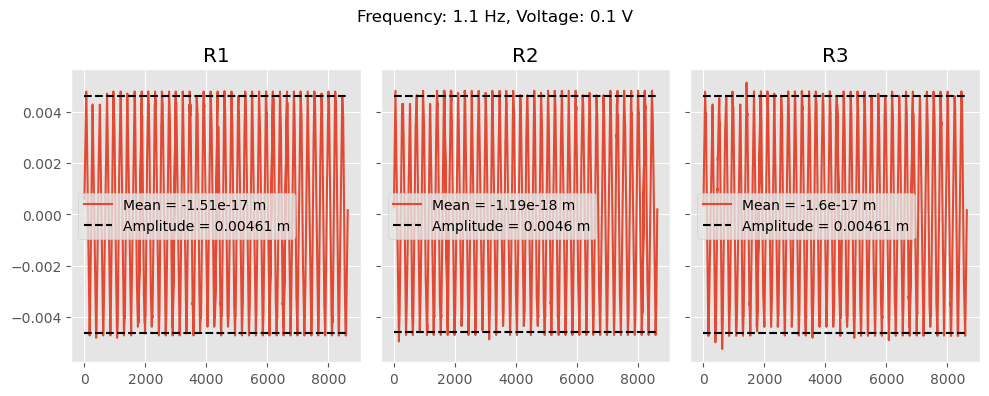

Frequency: 1.1, Voltage: 0.2


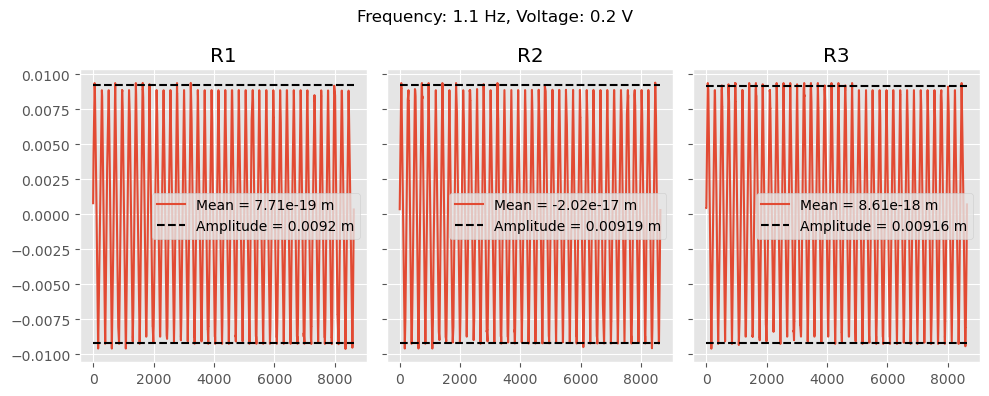

Frequency: 1.1, Voltage: 0.3


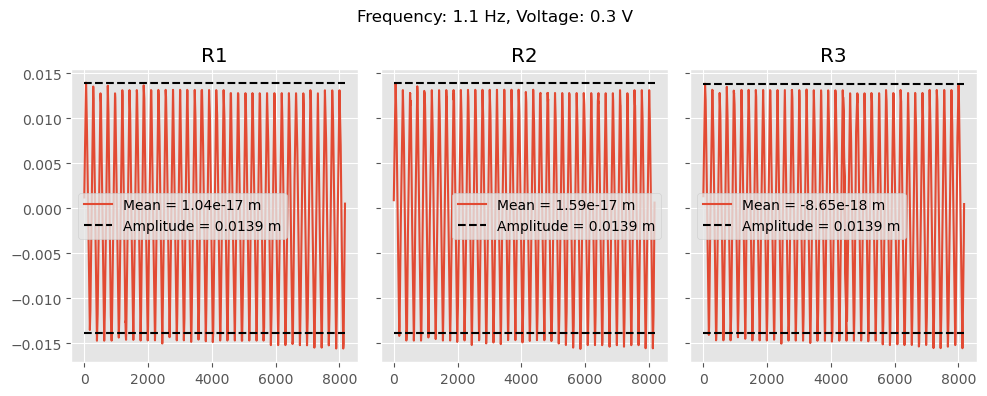

Frequency: 1.2, Voltage: 0.1


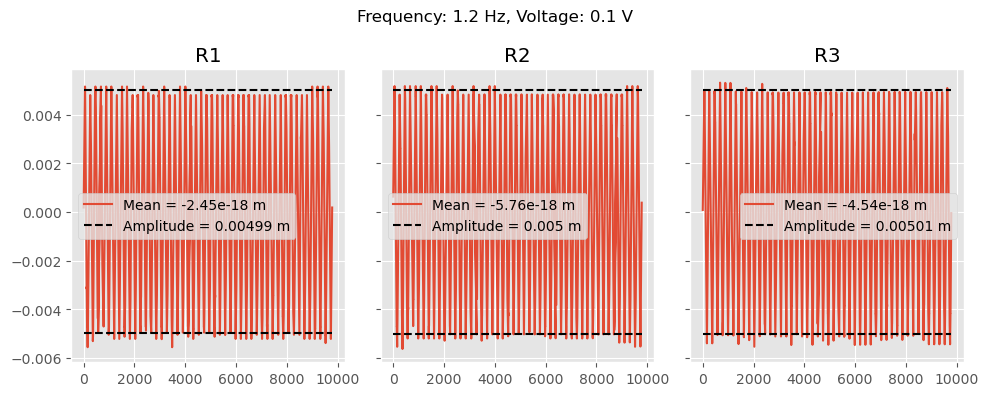

Frequency: 1.2, Voltage: 0.2


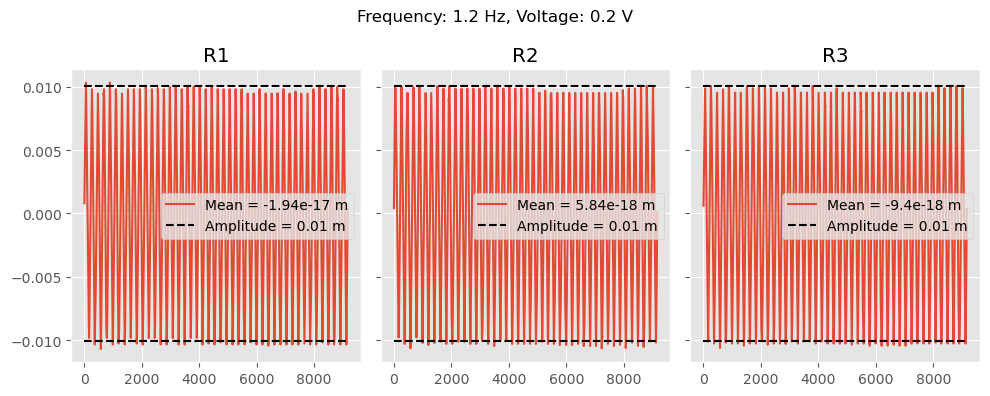

Frequency: 1.2, Voltage: 0.3


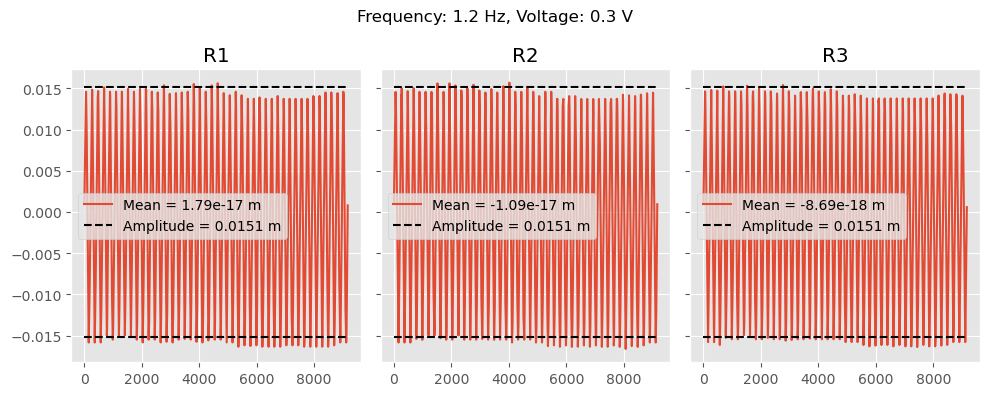

Frequency: 1.3, Voltage: 0.1


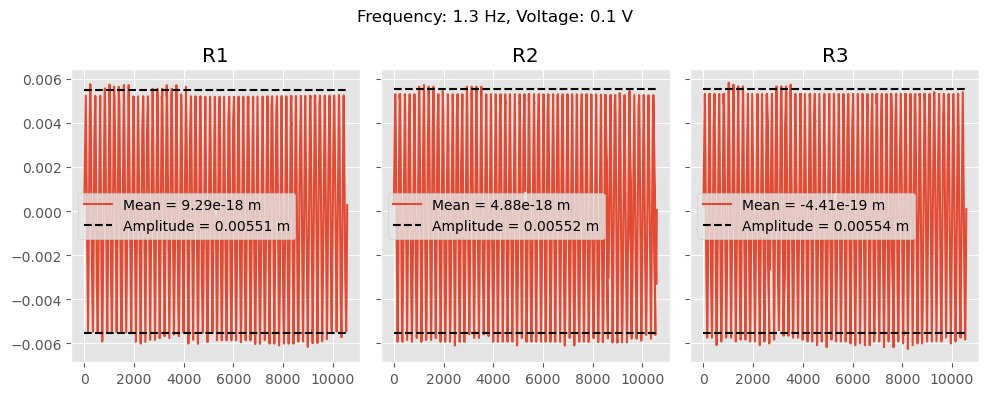

Frequency: 1.3, Voltage: 0.2


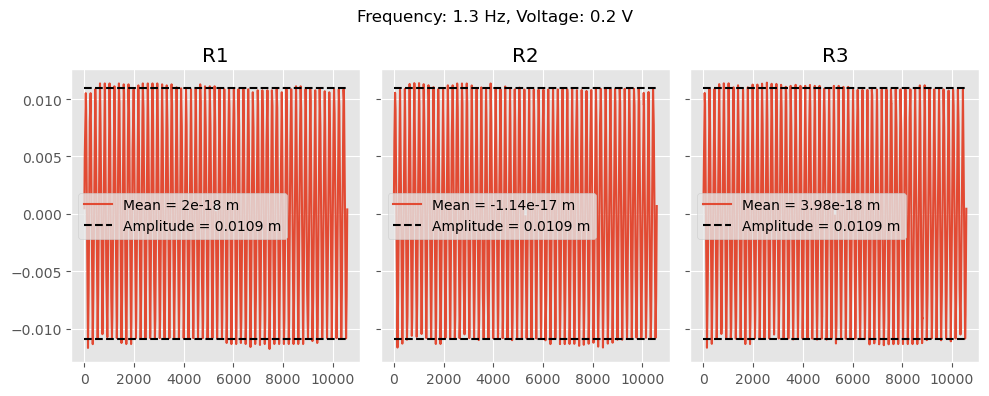

Frequency: 1.3, Voltage: 0.3


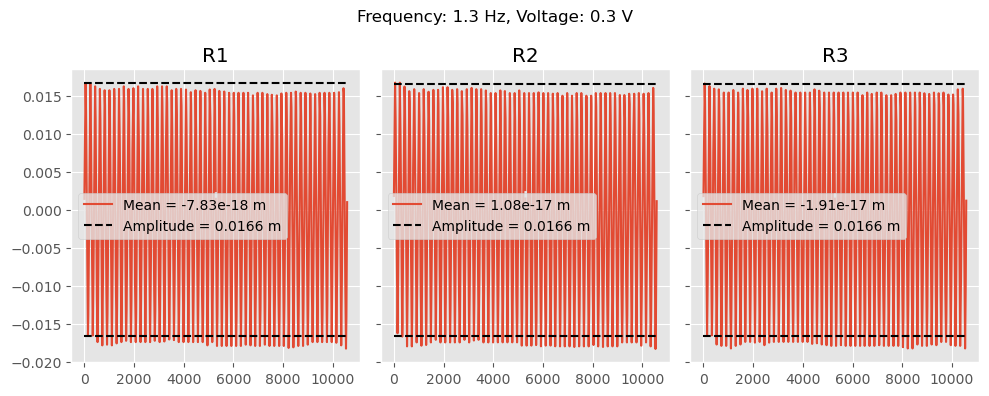

Frequency: 1.4, Voltage: 0.1


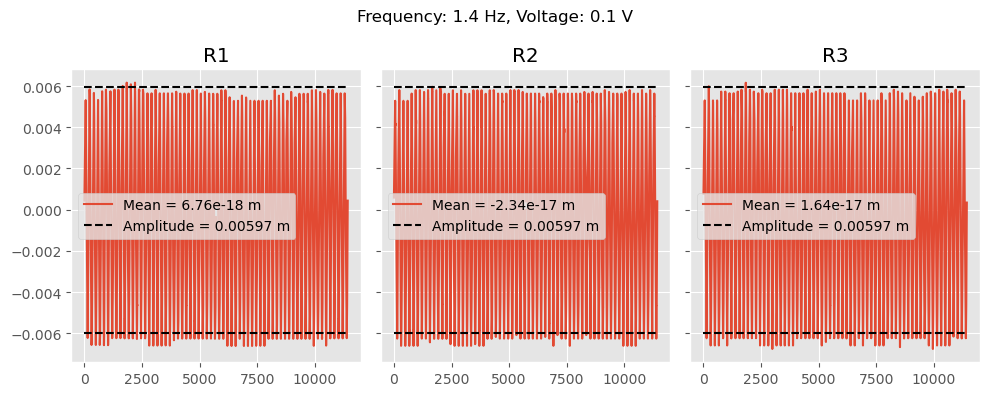

Frequency: 1.4, Voltage: 0.2


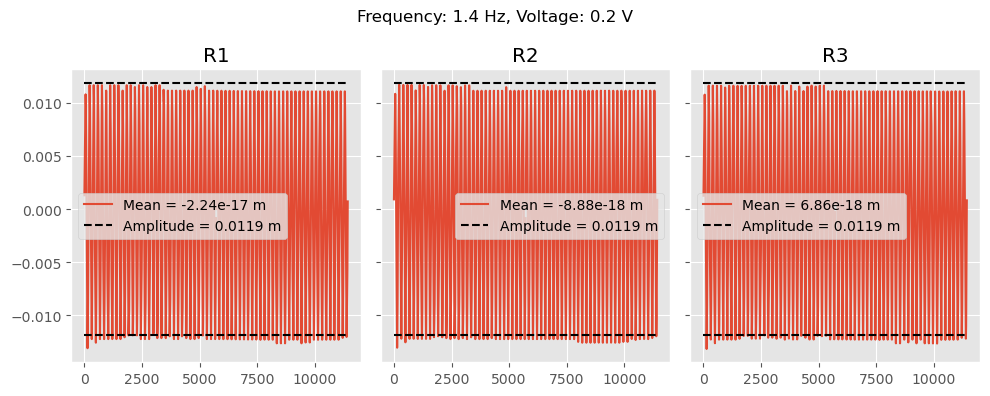

Frequency: 1.4, Voltage: 0.3


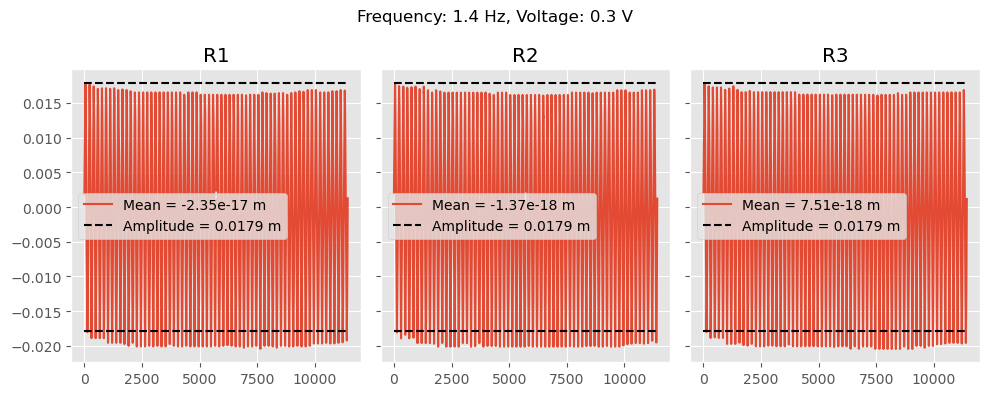

Frequency: 1.5, Voltage: 0.1


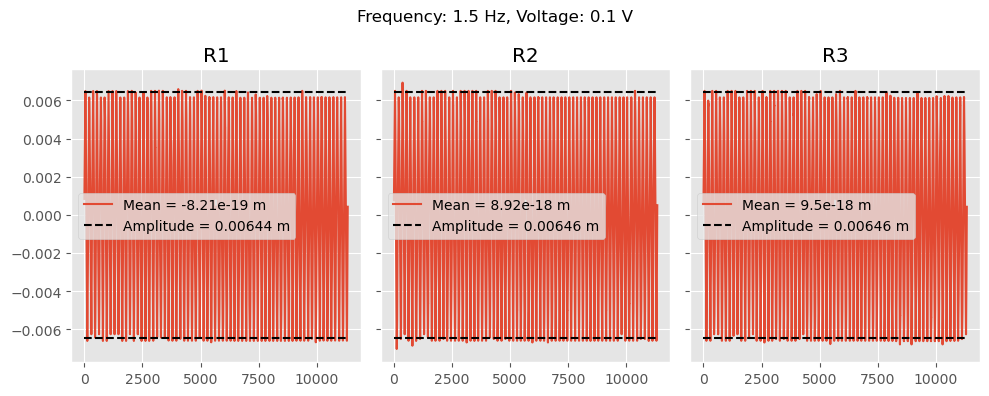

Frequency: 1.5, Voltage: 0.2


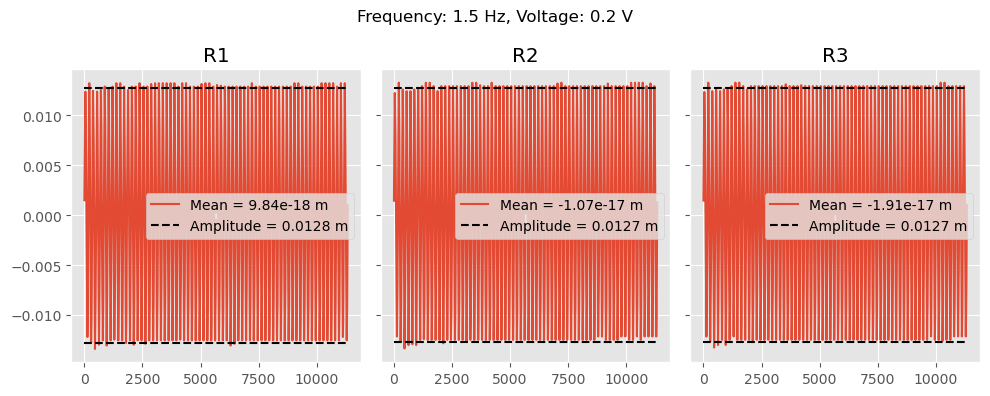

Frequency: 1.5, Voltage: 0.3


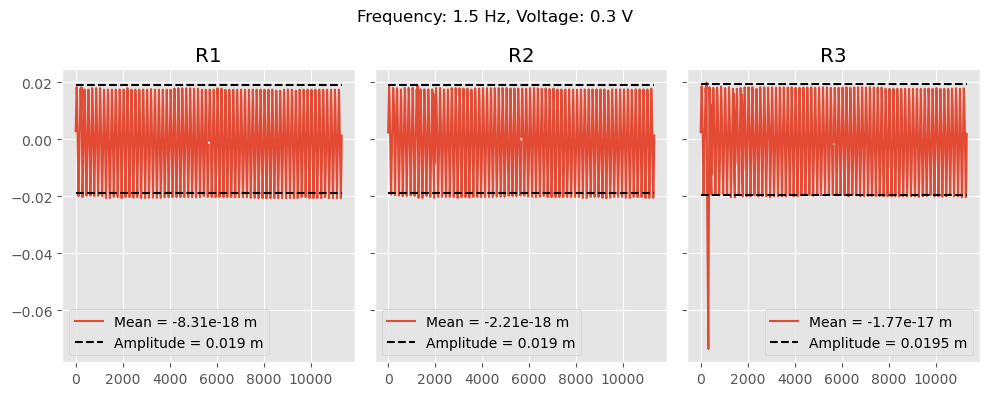

Frequency: 1.6, Voltage: 0.1


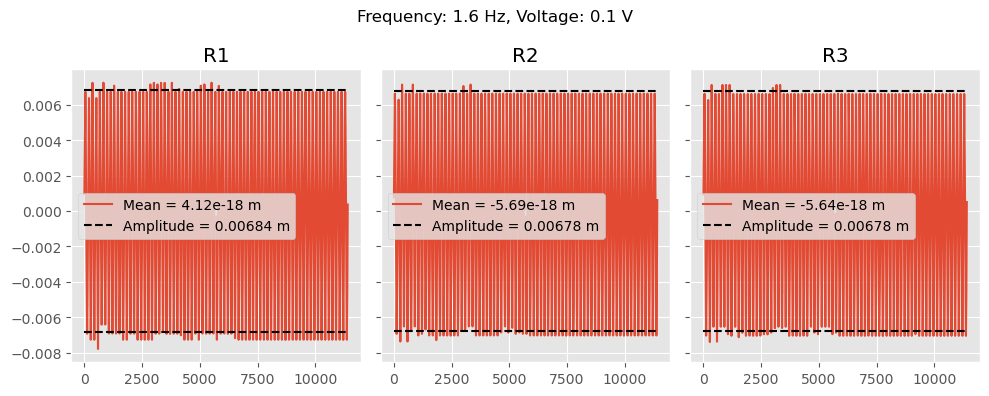

Frequency: 1.6, Voltage: 0.2


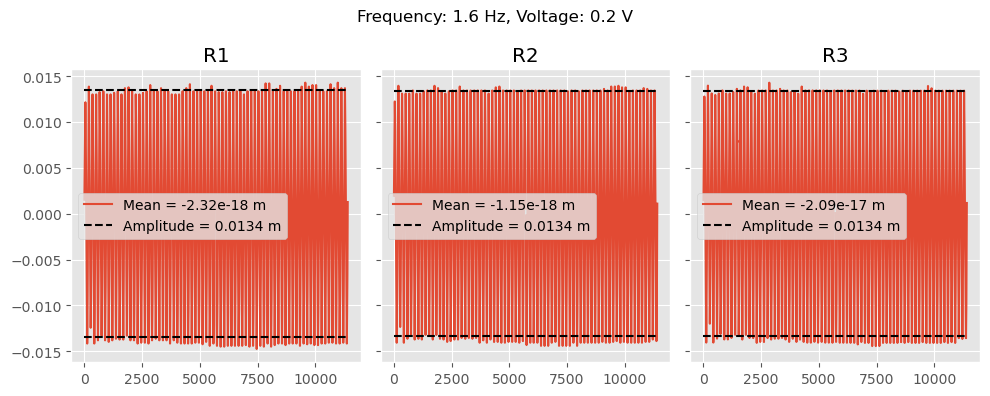

Frequency: 1.6, Voltage: 0.25


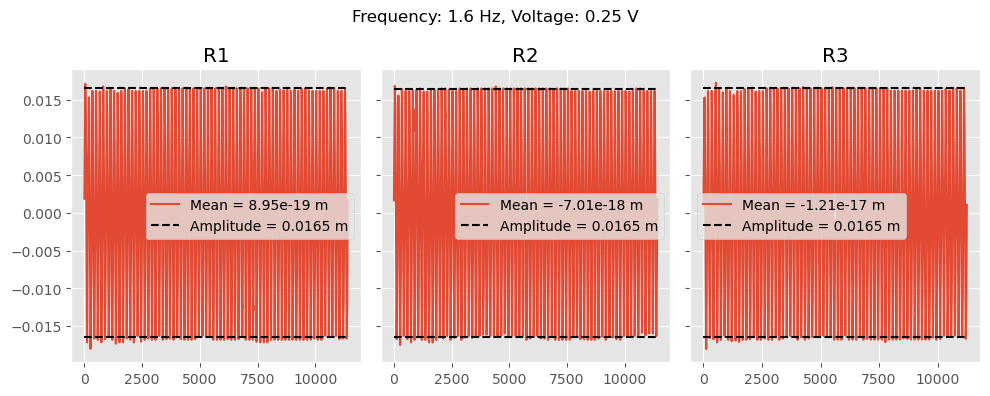

Frequency: 1.6, Voltage: 0.3


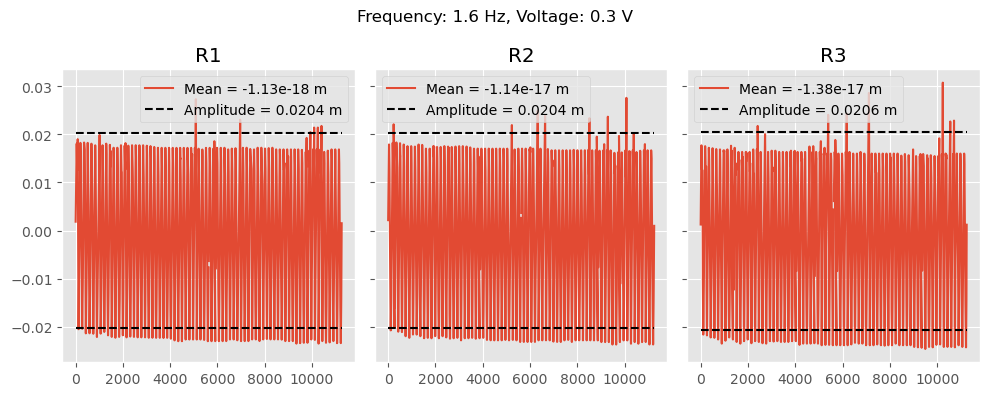

Frequency: 1.7, Voltage: 0.1


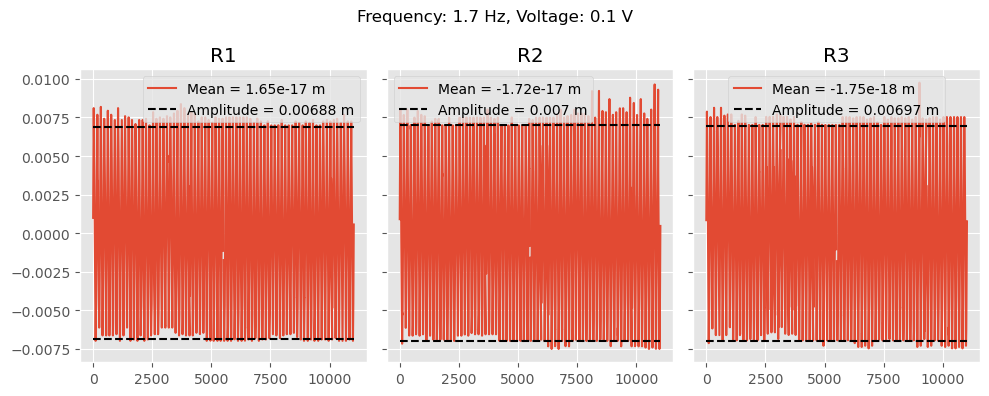

Frequency: 1.7, Voltage: 0.2


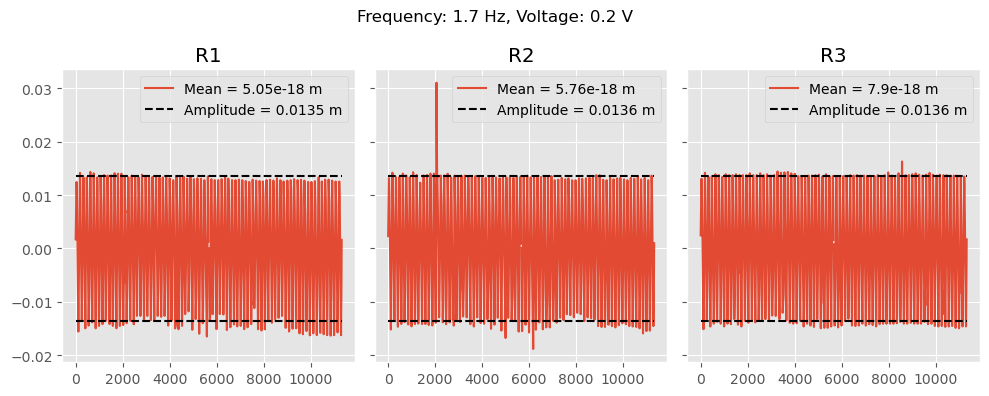

Frequency: 1.7, Voltage: 0.25


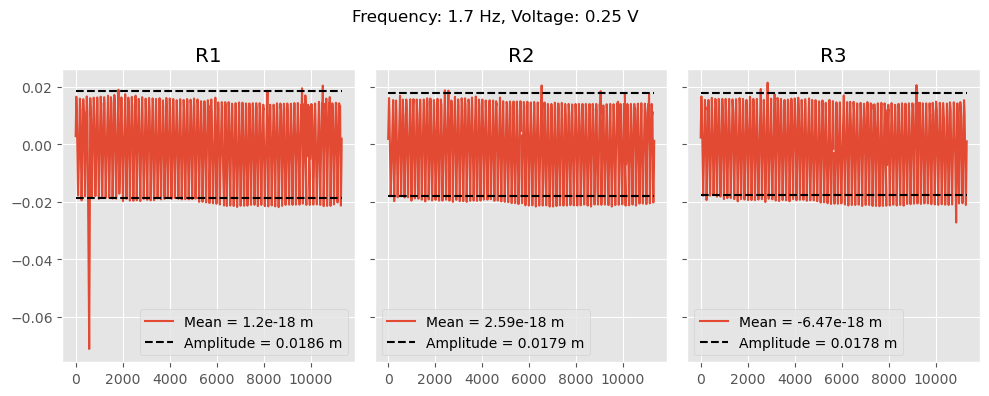

Frequency: 1.7, Voltage: 0.3


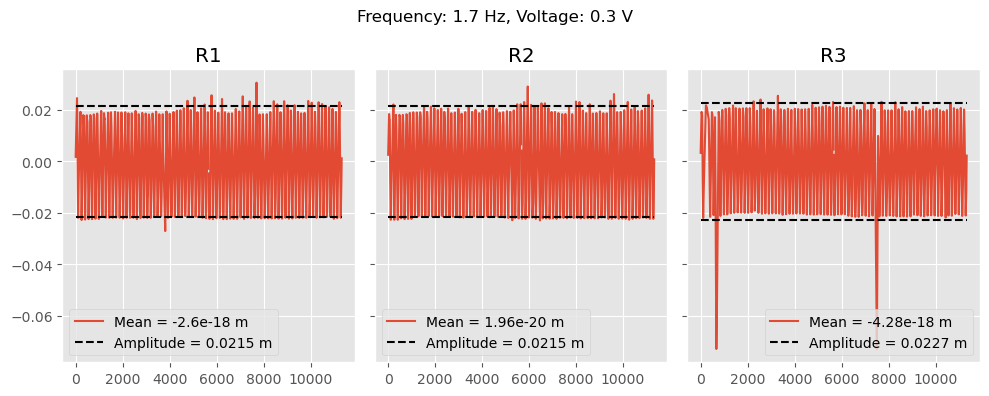

Frequency: 1.8, Voltage: 0.1


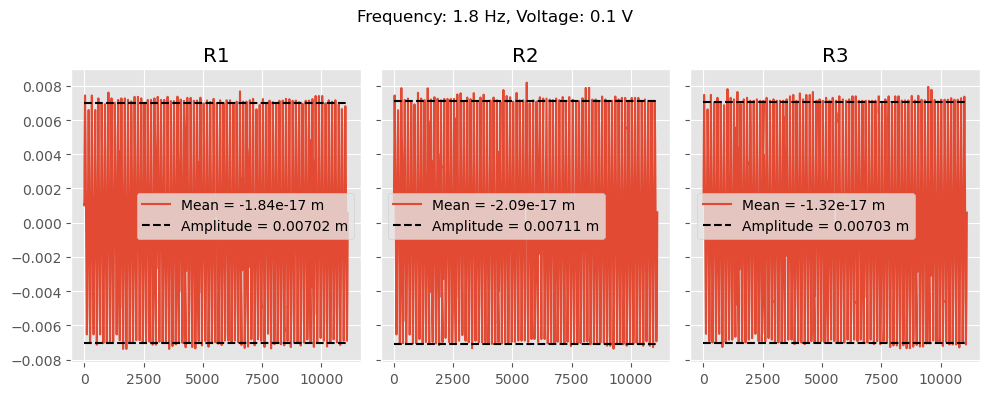

Frequency: 1.8, Voltage: 0.2


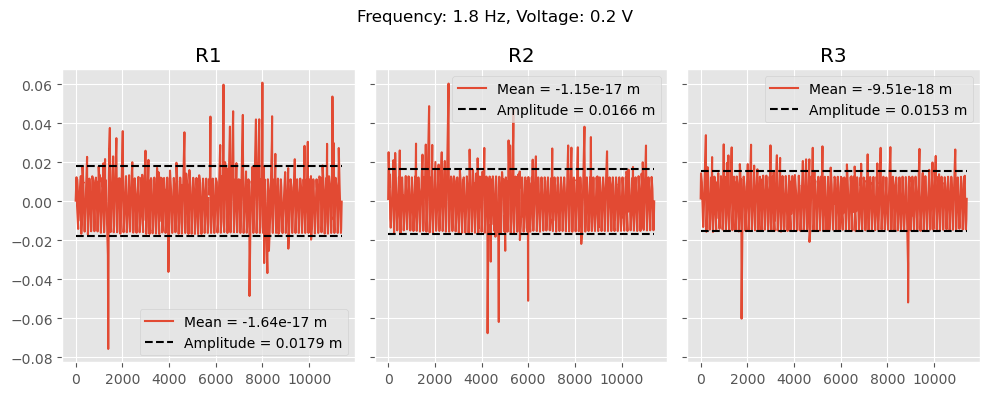

Frequency: 1.8, Voltage: 0.25


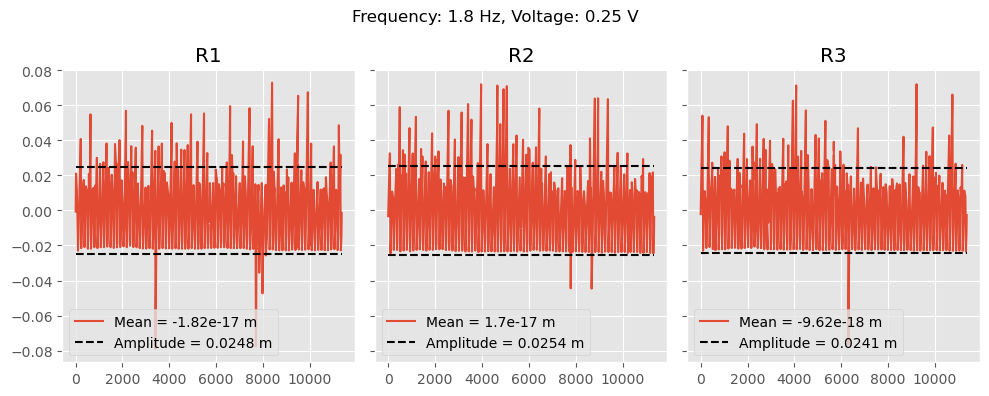

Frequency: 1.8, Voltage: 0.3


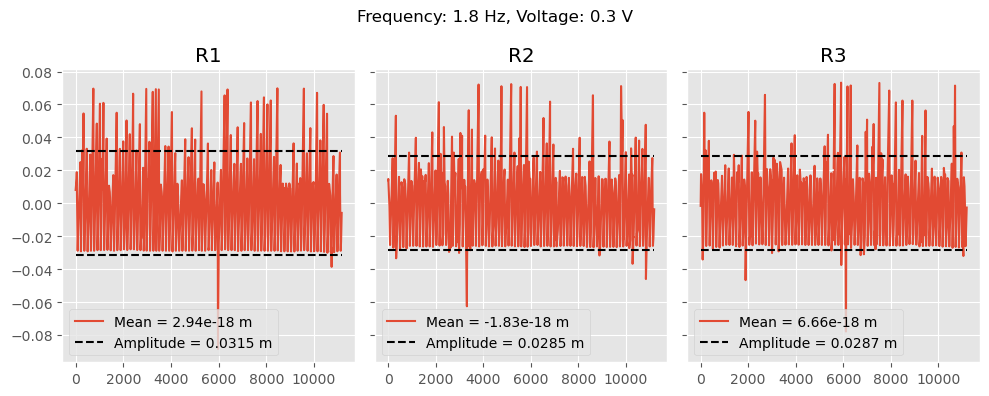

In [22]:
for i, f in enumerate(freqs):
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                eta_r1 = data[f][v][None]["R1"]
                eta_r2 = data[f][v][None]["R2"]
                eta_r3 = data[f][v][None]["R3"]

                P0_r1 = eta_r1["P_0"].dropna().values
                P0_r2 = eta_r2["P_0"].dropna().values
                P0_r3 = eta_r3["P_0"].dropna().values

                std_P0_r1 = np.std(P0_r1)
                std_P0_r2 = np.std(P0_r2)
                std_P0_r3 = np.std(P0_r3)

                amp_P0_r1 = np.sqrt(2) * std_P0_r1
                amp_P0_r2 = np.sqrt(2) * std_P0_r2
                amp_P0_r3 = np.sqrt(2) * std_P0_r3

                fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
                ax[0].plot(P0_r1, color='C0', label=f'Mean = {np.mean(P0_r1):.3g} m')
                ax[1].plot(P0_r2, color='C0', label=f'Mean = {np.mean(P0_r2):.3g} m')
                ax[2].plot(P0_r3, color='C0', label=f'Mean = {np.mean(P0_r3):.3g} m')

                ax[0].hlines(amp_P0_r1, xmin=0, xmax=len(P0_r1)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r1:.3g} m")
                ax[0].hlines(-amp_P0_r1, xmin=0, xmax=len(P0_r1)-1, color='k', linestyle='--')
                ax[1].hlines(amp_P0_r2, xmin=0, xmax=len(P0_r2)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r2:.3g} m")
                ax[1].hlines(-amp_P0_r2, xmin=0, xmax=len(P0_r2)-1, color='k', linestyle='--')
                ax[2].hlines(amp_P0_r3, xmin=0, xmax=len(P0_r3)-1, color='k', linestyle='--', label=f"Amplitude = {amp_P0_r3:.3g} m")
                ax[2].hlines(-amp_P0_r3, xmin=0, xmax=len(P0_r3)-1, color='k', linestyle='--')  

                ax[0].set_title("R1")
                ax[1].set_title("R2")
                ax[2].set_title("R3")

                ax[0].legend()
                ax[1].legend()
                ax[2].legend()

                fig.suptitle(f"Frequency: {f} Hz, Voltage: {v} V")
            
                plt.tight_layout()
                plt.show()
            

In [25]:
# Test to find local peaks
probedata = data[1.4][0.3]['p005']["R1"]
p0 = probedata['P_0'].dropna().values * -1
p3 = probedata['P_3'].dropna().values * -1

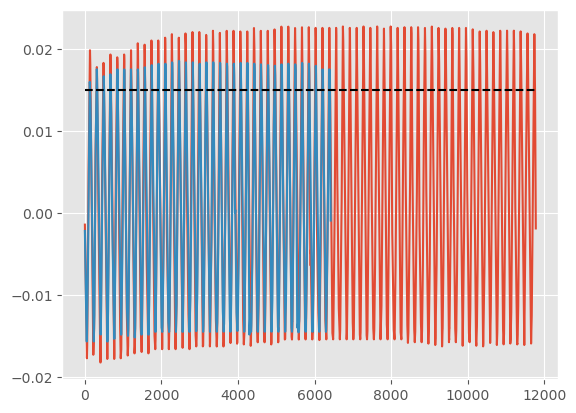

In [49]:
plt.plot(p0)
plt.plot(p3)
plt.hlines(0.015, xmin=0, xmax=len(p0)-1, color='k', linestyle='--')

In [56]:
from scipy.signal import find_peaks

peak_idx = find_peaks(p0, 0.015)
amps_p0 = []
for idx in peak_idx[0]:
    amps_p0.append(p0[idx])

# Only keep positive peaks
amps_p0 = [amp for amp in amps_p0 if amp > 0]
#amps_p0 = np.abs(amps_p0)

In [ ]:
peak_idx = find_peaks(p3, 0.015)
amps_p3 = []
for idx in peak_idx[0]:
    amps_p3.append(p3[idx])

# Only keep positive peaks
amps_p3 = [amp for amp in amps_p3 if amp > 0]

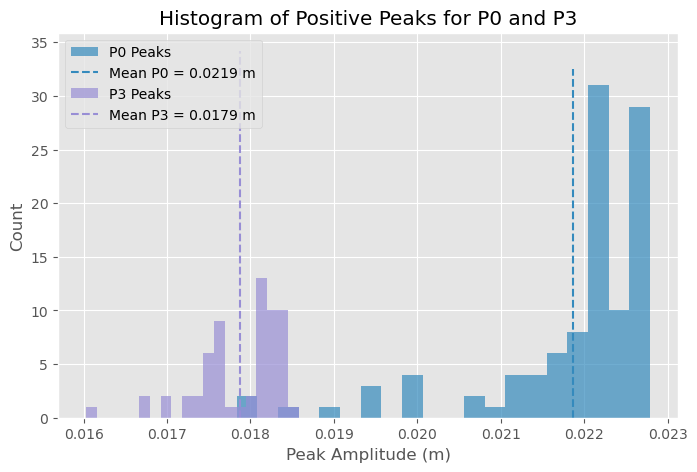

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(amps_p0, color='C1', bins=20, alpha=0.7, label='P0 Peaks')
ax.vlines(x=np.mean(amps_p0), ymin=0, ymax=ax.get_ylim()[1], linestyle='--', color='C1', label=f'Mean P0 = {np.mean(amps_p0):.3g} m')
ax.hist(amps_p3, color='C2', bins=20, alpha=0.7, label='P3 Peaks')
ax.vlines(x=np.mean(amps_p3), ymin=0, ymax=ax.get_ylim()[1], linestyle='--', color='C2', label=f'Mean P3 = {np.mean(amps_p3):.3g} m')
ax.set_xlabel("Peak Amplitude (m)")
ax.set_ylabel("Count")
ax.set_title("Histogram of Positive Peaks for P0 and P3")
ax.legend()

In [23]:
str(v).replace('.', '')

'03'

Frequency: 1.1, Voltage: 0.1


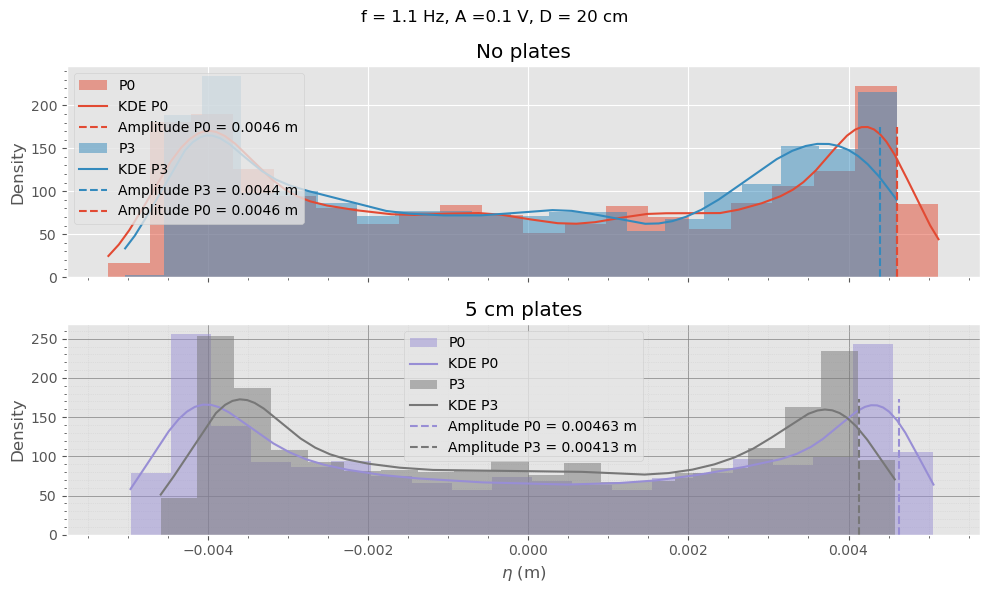

Frequency: 1.1, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

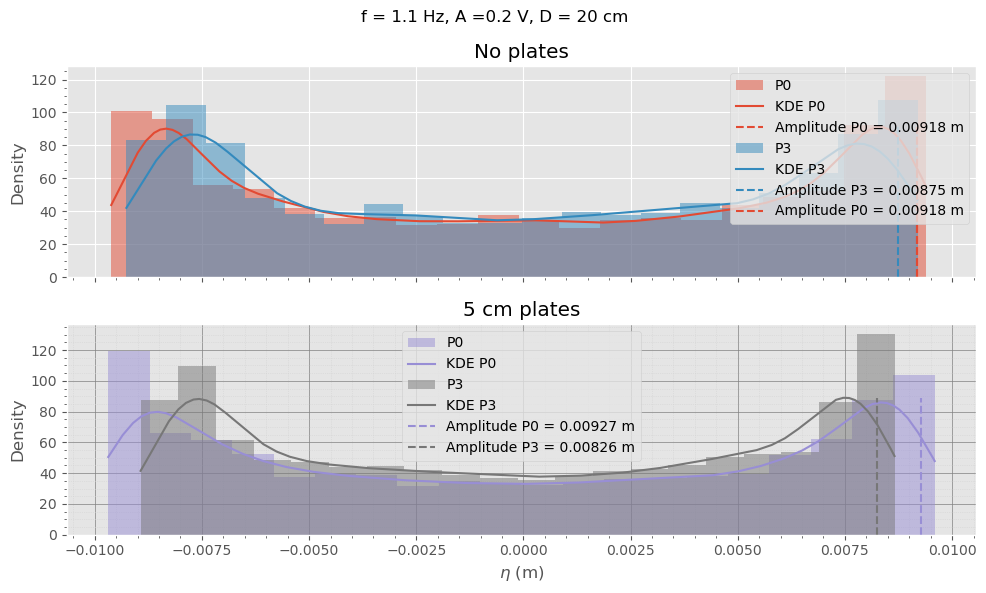

Frequency: 1.1, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

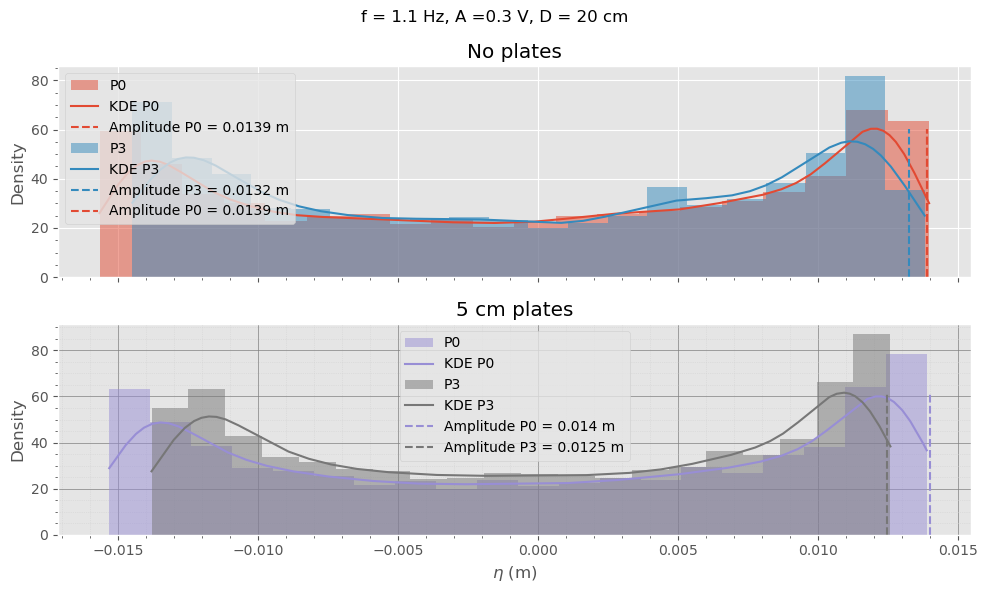

Frequency: 1.2, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

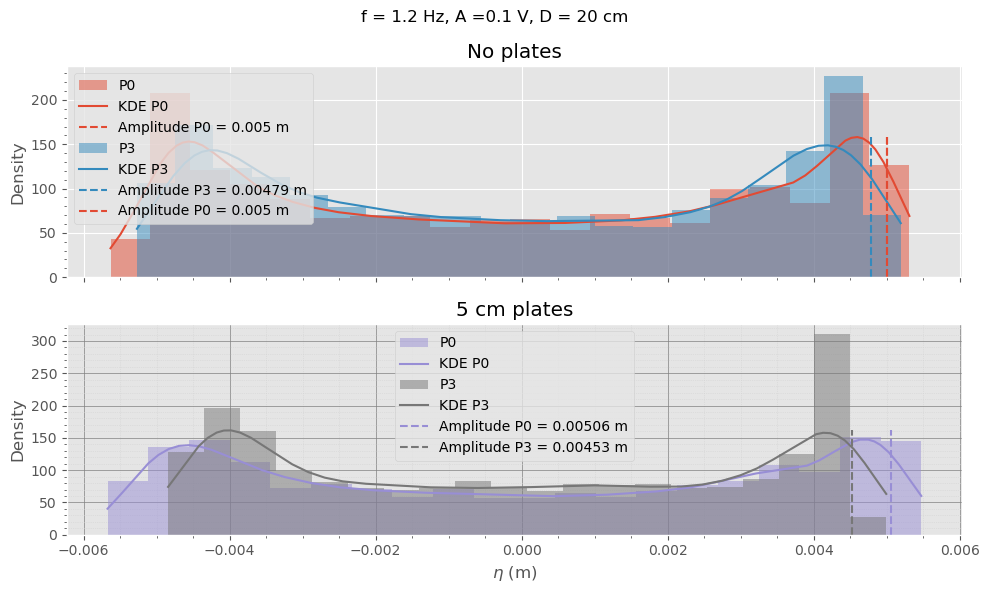

Frequency: 1.2, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

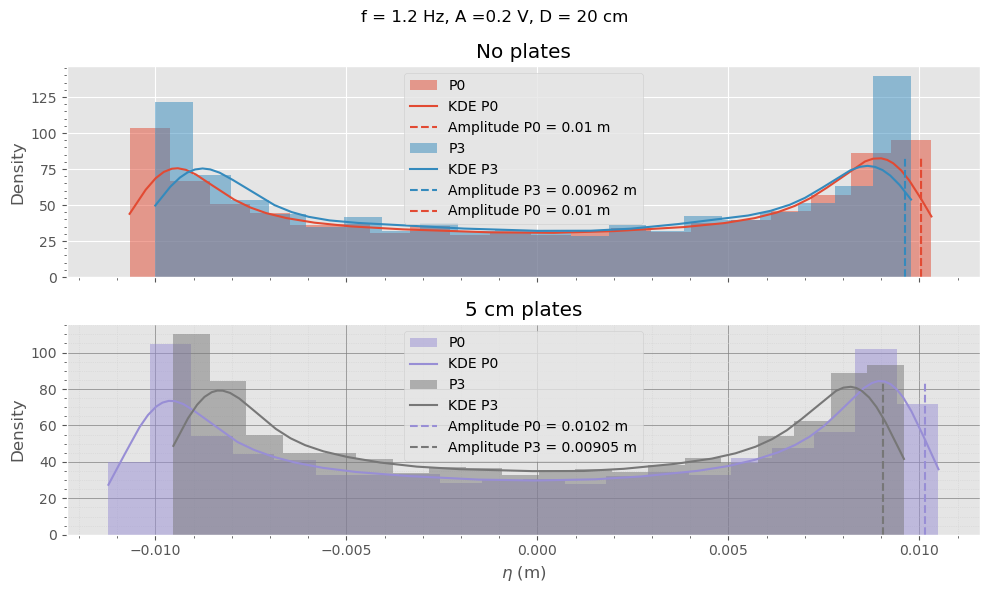

Frequency: 1.2, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

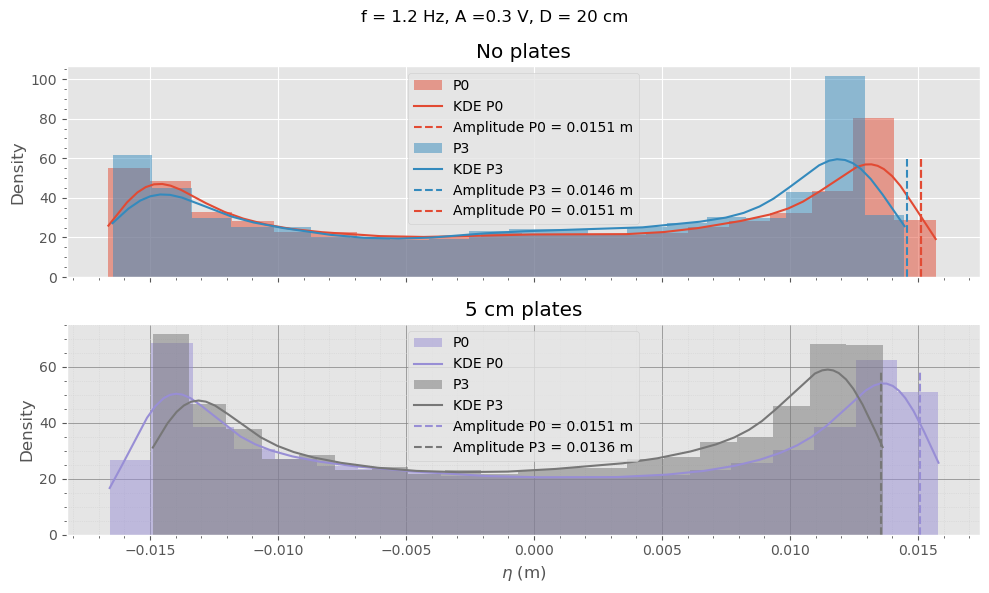

Frequency: 1.3, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

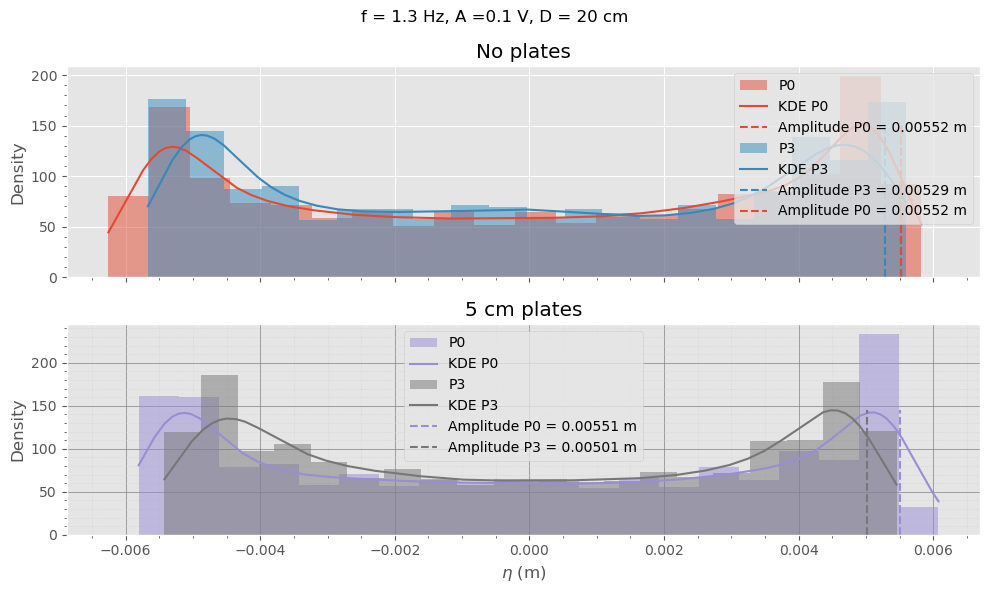

Frequency: 1.3, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

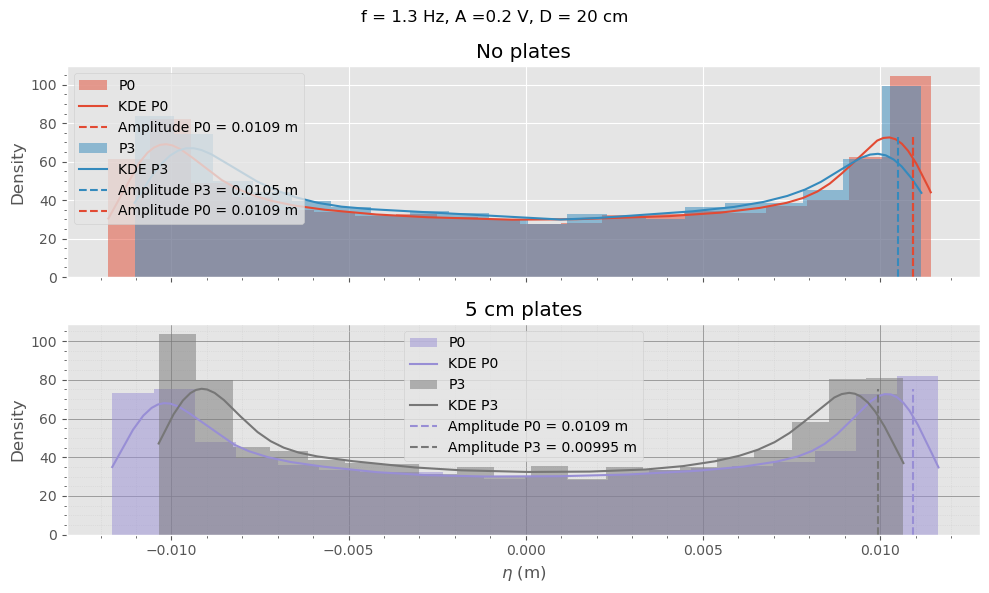

Frequency: 1.3, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

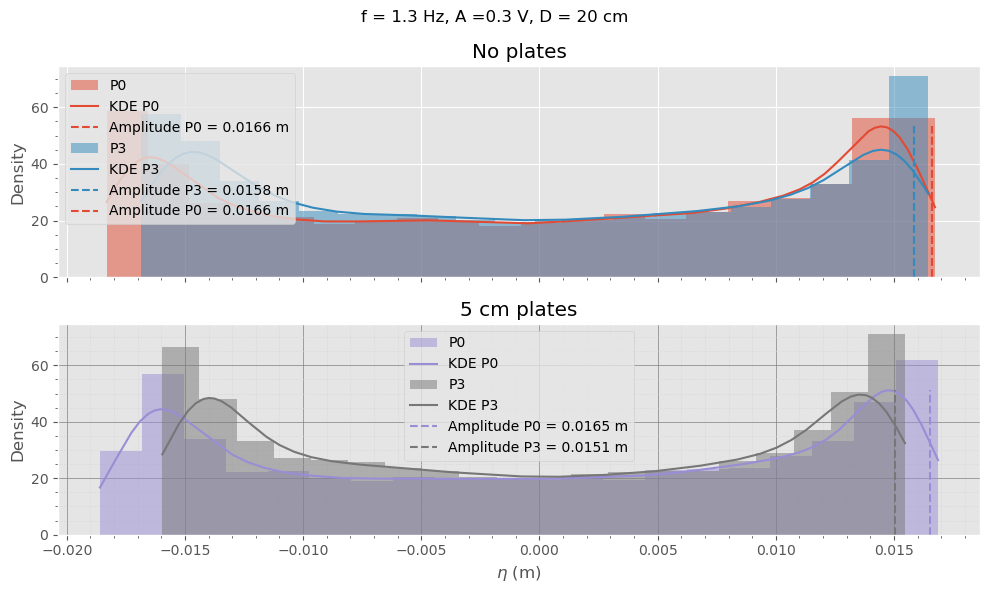

Frequency: 1.4, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

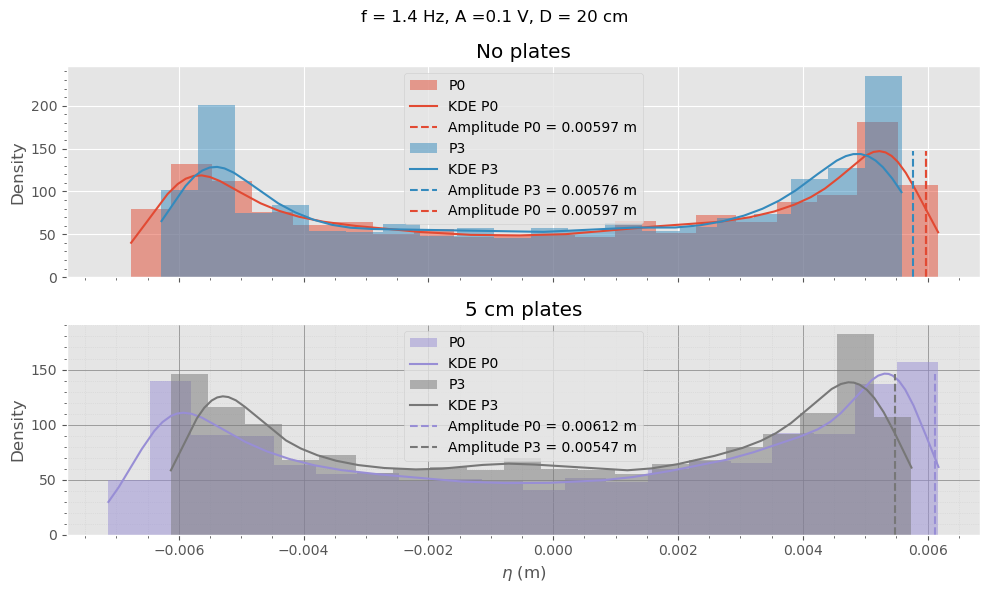

Frequency: 1.4, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

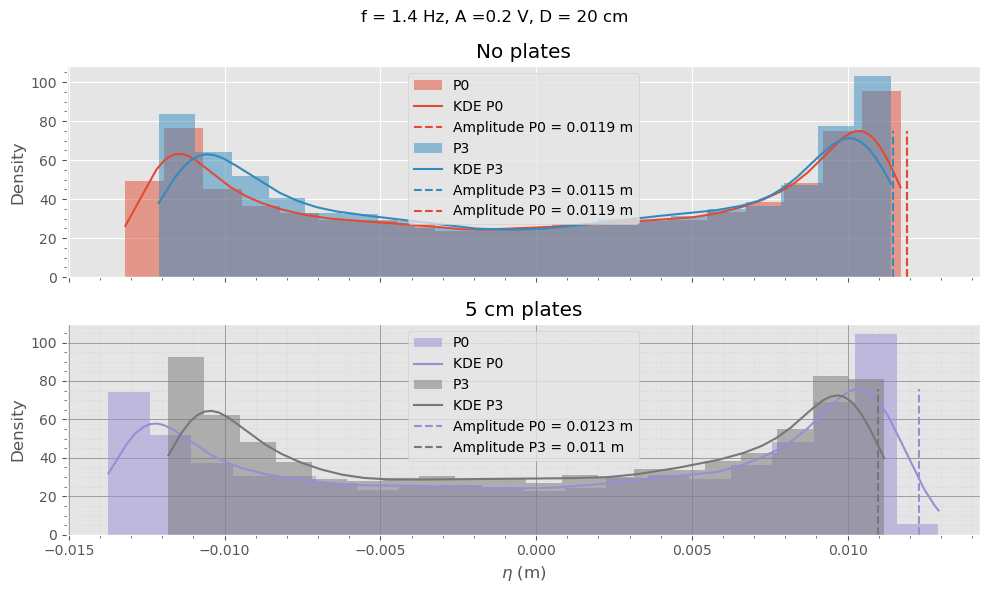

Frequency: 1.4, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

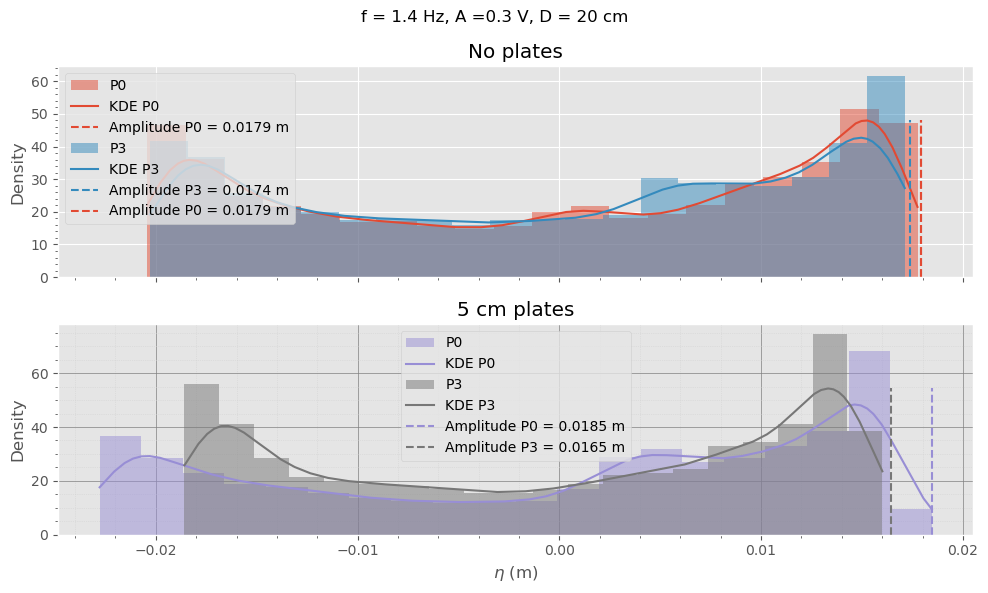

Frequency: 1.5, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

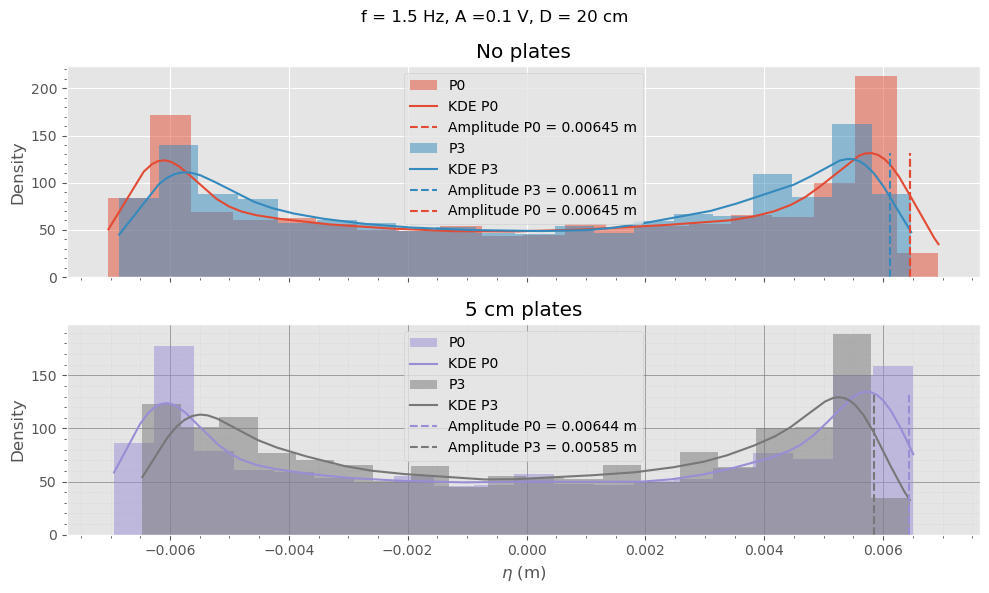

Frequency: 1.5, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

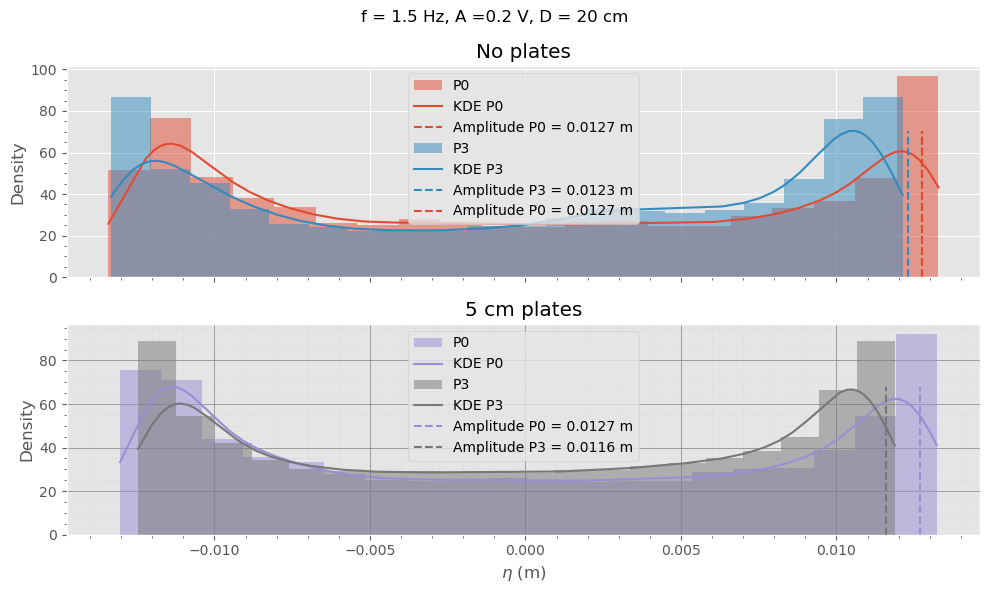

Frequency: 1.5, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

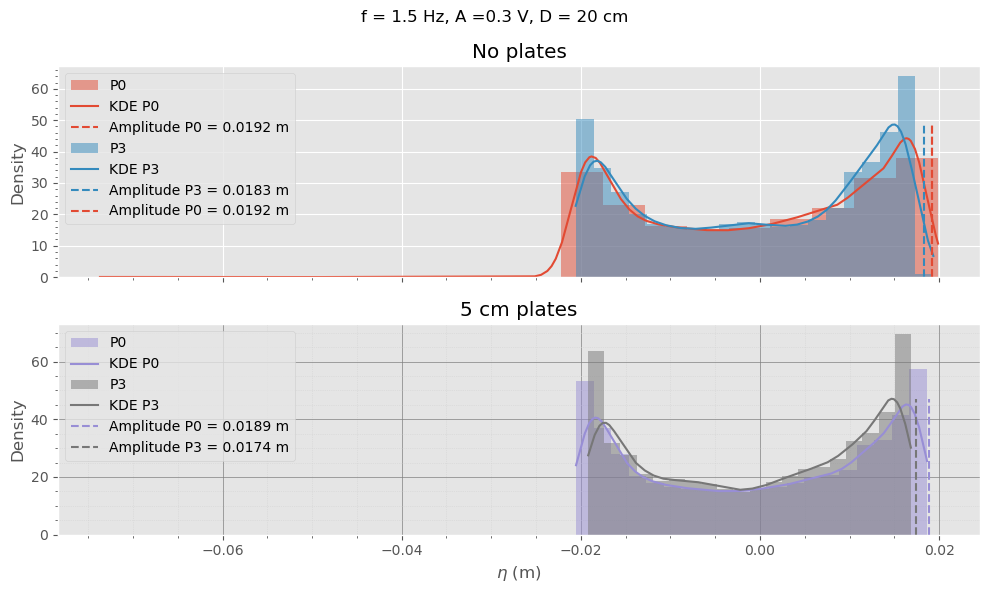

Frequency: 1.6, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

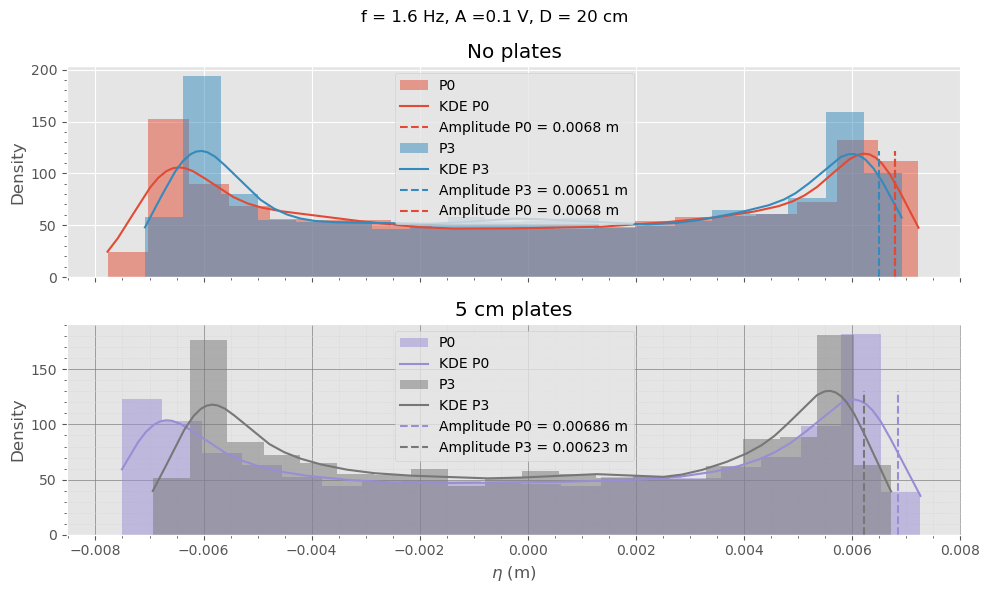

Frequency: 1.6, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

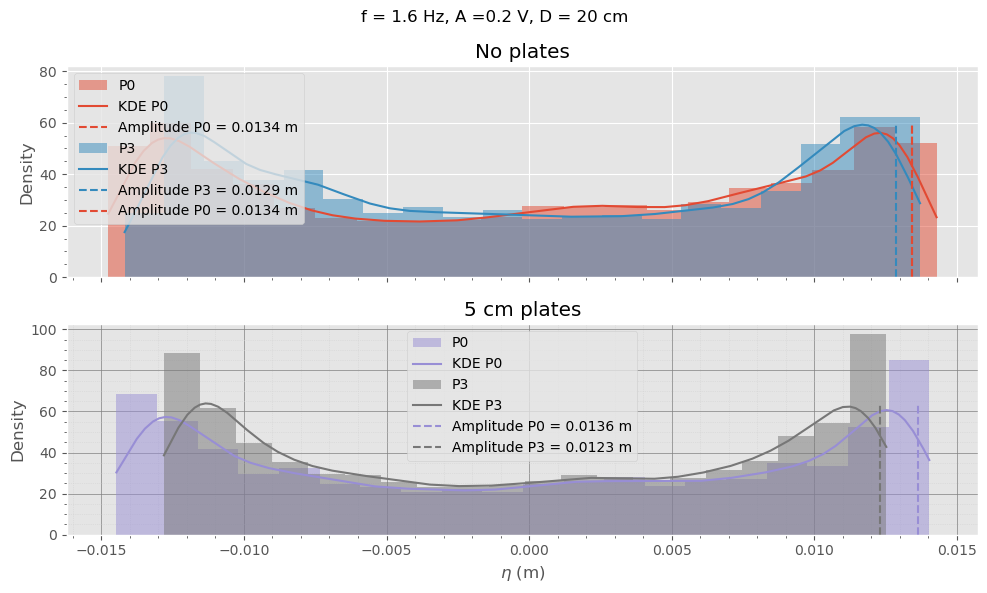

Frequency: 1.6, Voltage: 0.25


<Figure size 640x480 with 0 Axes>

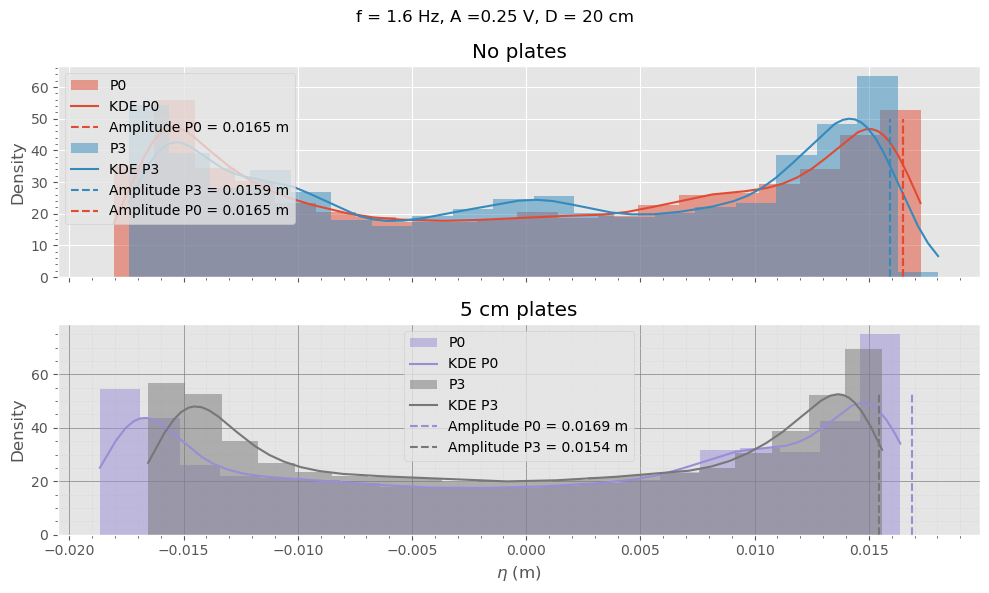

Frequency: 1.6, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

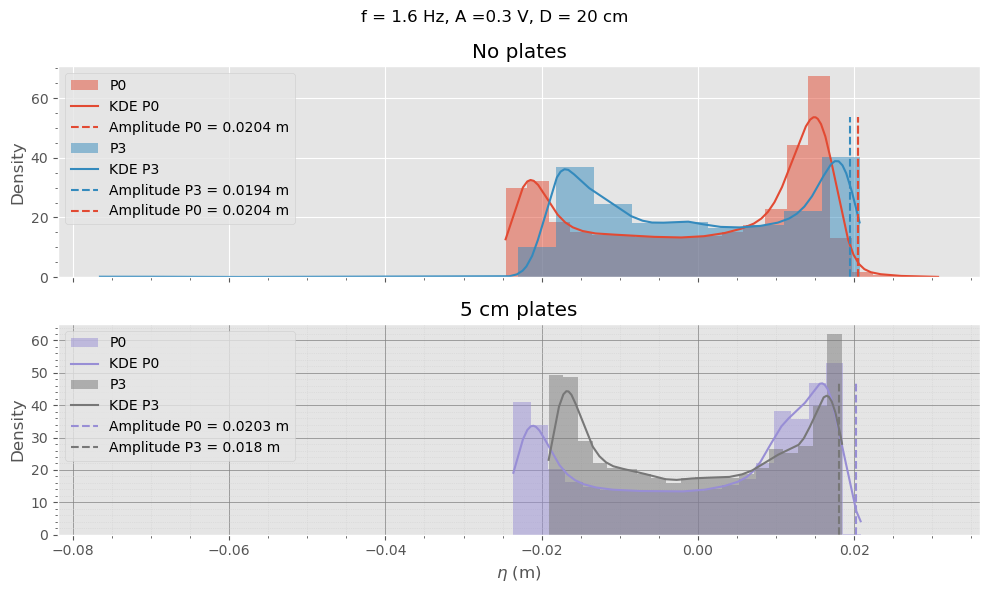

Frequency: 1.7, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

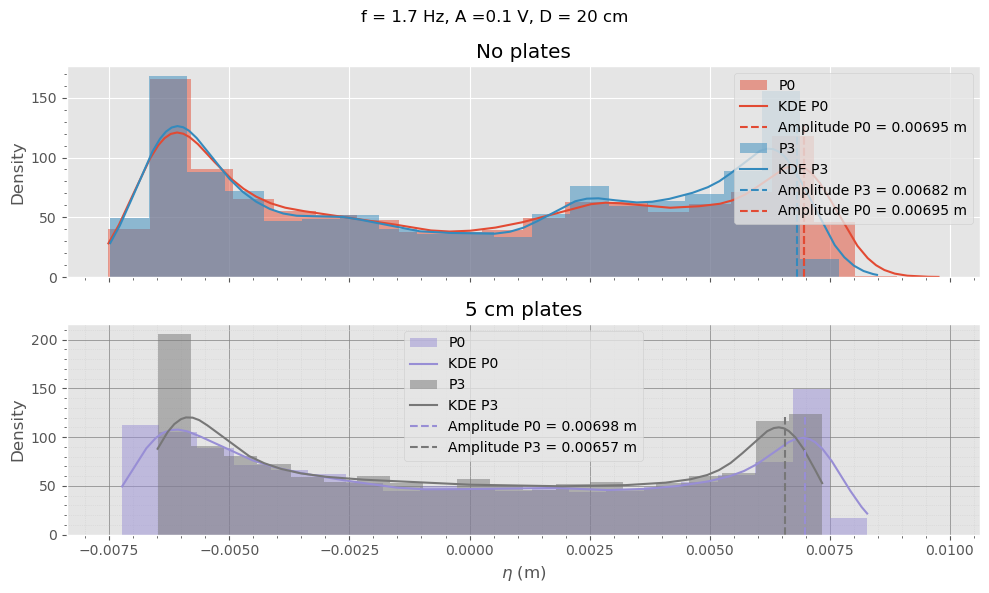

Frequency: 1.7, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

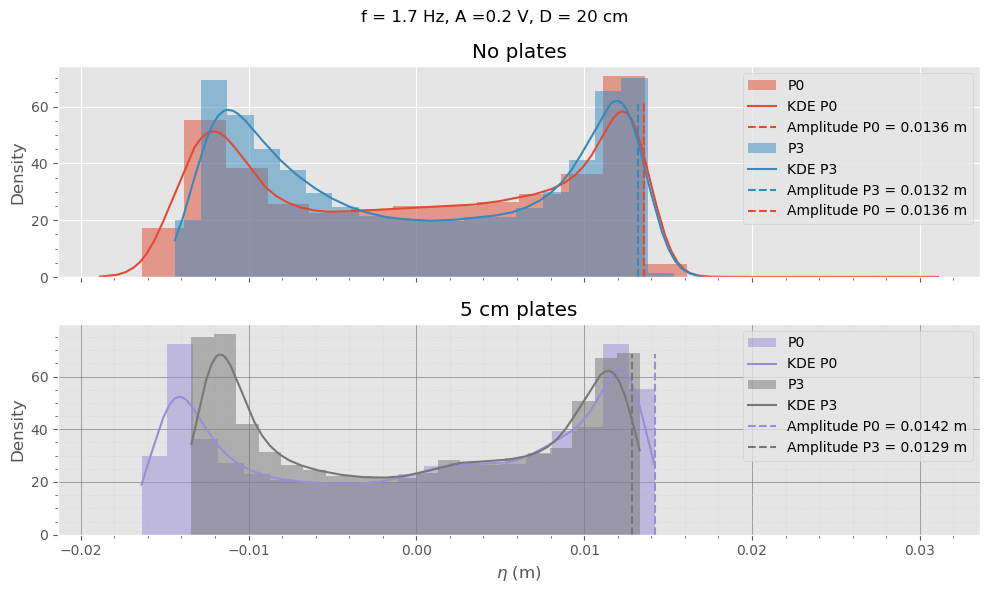

Frequency: 1.7, Voltage: 0.25


<Figure size 640x480 with 0 Axes>

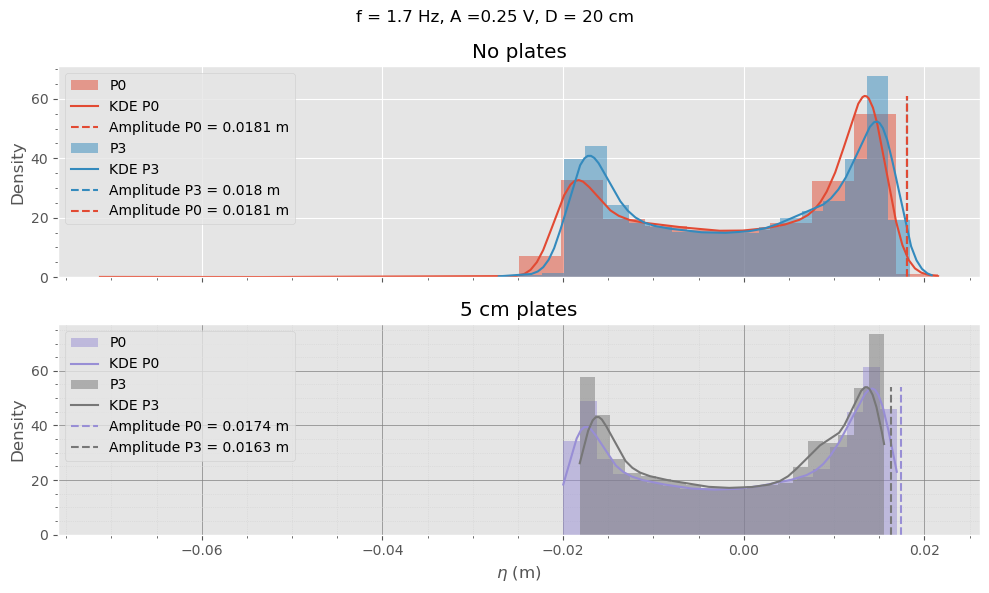

Frequency: 1.7, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

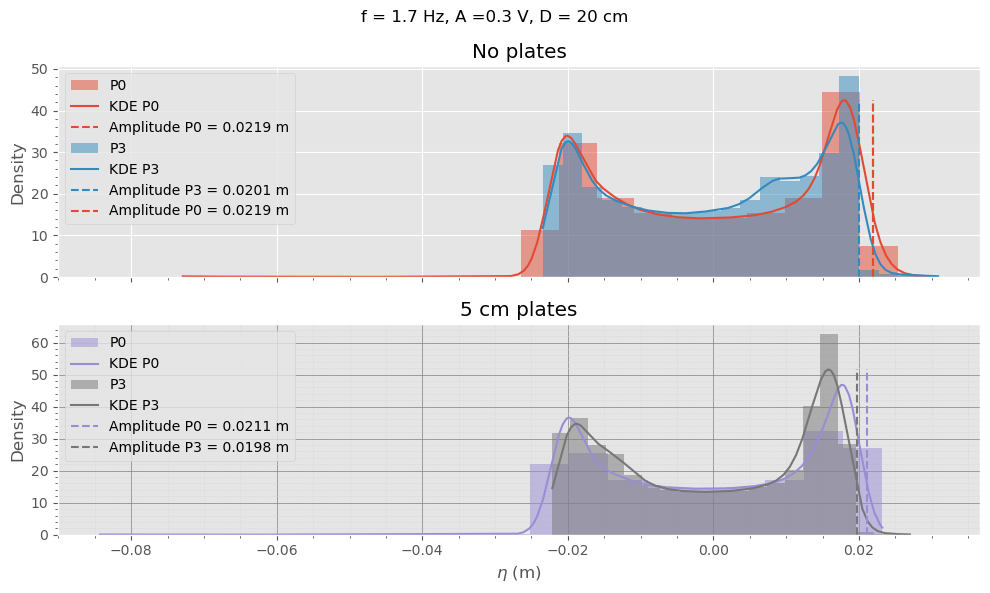

Frequency: 1.8, Voltage: 0.1


<Figure size 640x480 with 0 Axes>

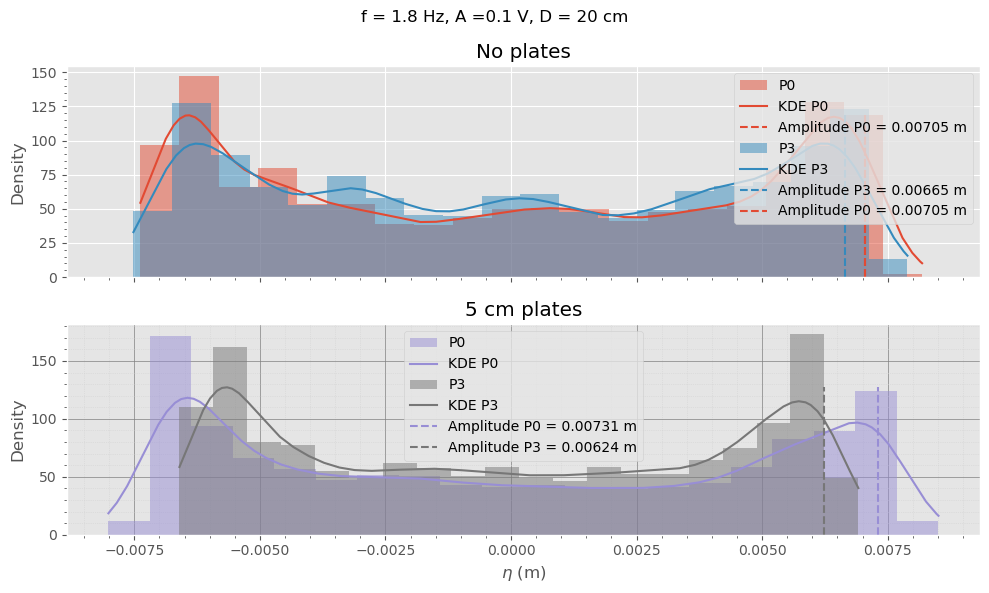

Frequency: 1.8, Voltage: 0.2


<Figure size 640x480 with 0 Axes>

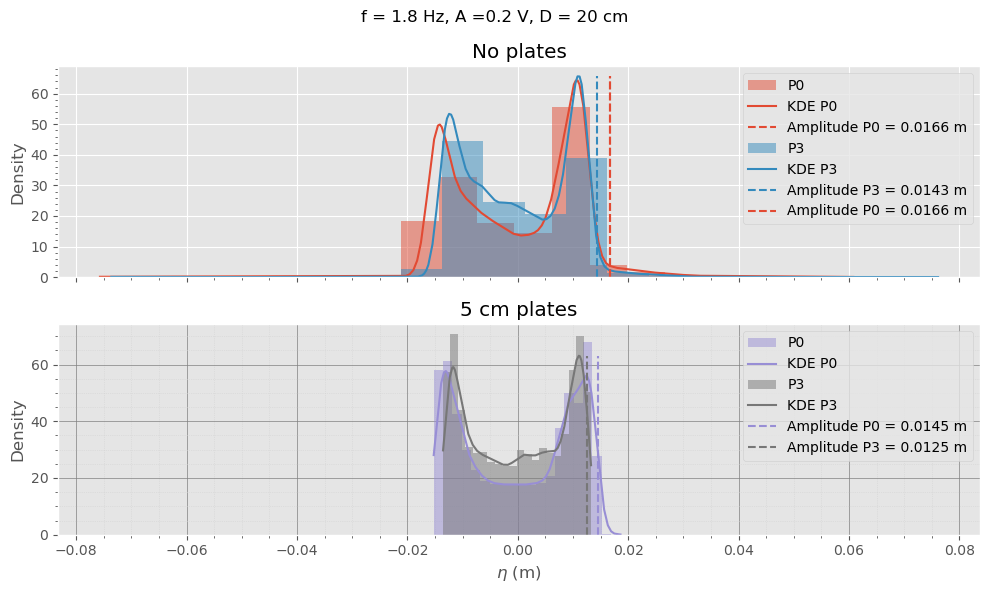

Frequency: 1.8, Voltage: 0.25


<Figure size 640x480 with 0 Axes>

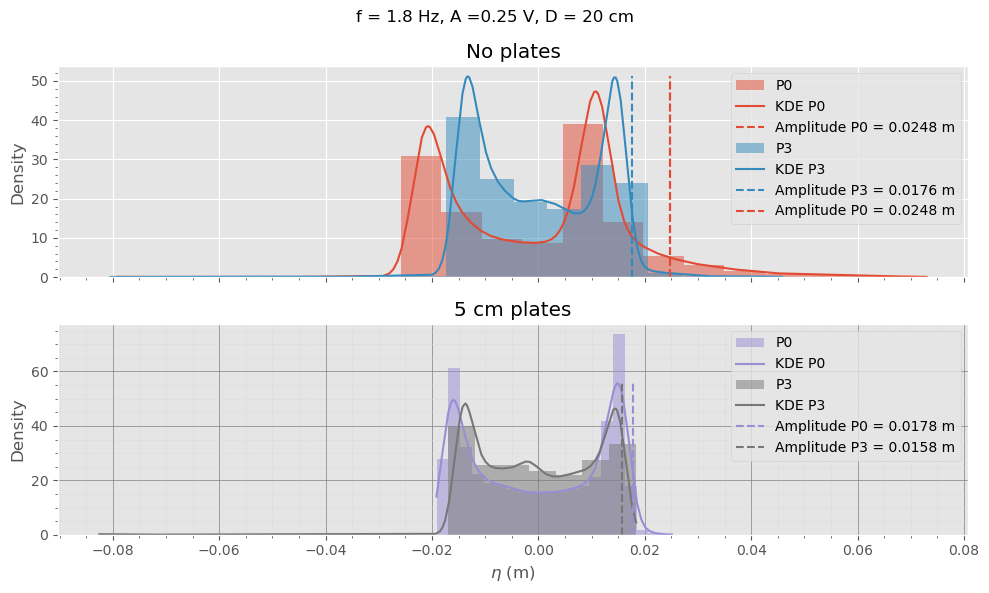

Frequency: 1.8, Voltage: 0.3


<Figure size 640x480 with 0 Axes>

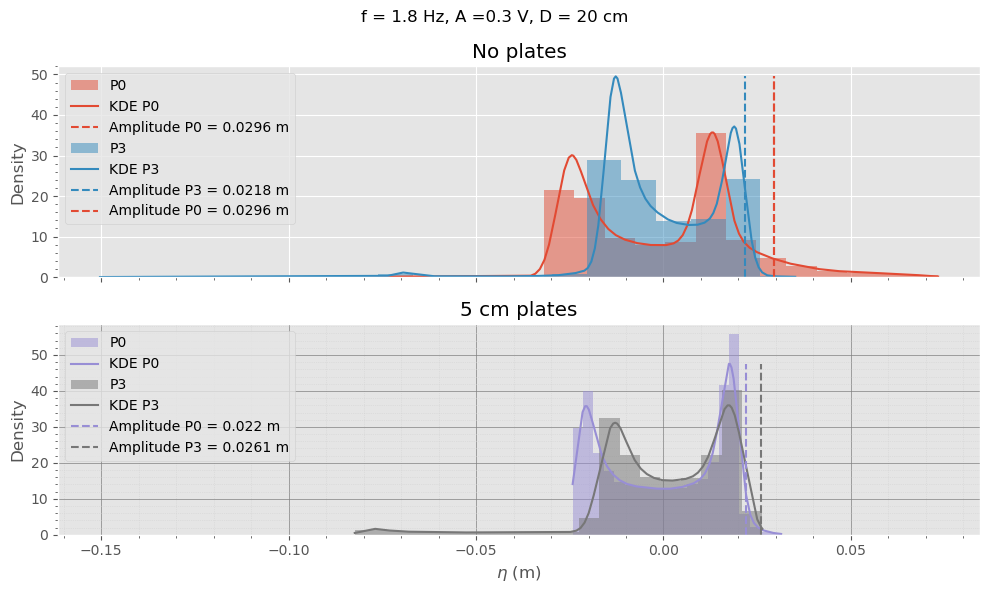

<Figure size 640x480 with 0 Axes>

In [24]:
for i, f in enumerate(freqs):
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                # No plates
                eta_r1 = data[f][v][None]["R1"]
                eta_r2 = data[f][v][None]["R2"]
                eta_r3 = data[f][v][None]["R3"]

                P0_r1 = eta_r1["P_0"].dropna().values
                P0_r2 = eta_r2["P_0"].dropna().values
                P0_r3 = eta_r3["P_0"].dropna().values

                P0 = np.concatenate([P0_r1, P0_r2, P0_r3])

                P0_amp = np.sqrt(2) * np.std(P0)

                # KDE
                kde_P0 = stats.gaussian_kde(P0)
                xs_P0 = np.linspace(P0.min(), P0.max(), 400)
                pdf_kde_P0 = kde_P0(xs_P0)

                P3_r1 = eta_r1["P_3"].dropna().values
                P3_r2 = eta_r2["P_3"].dropna().values
                P3_r3 = eta_r3["P_3"].dropna().values

                P3 = np.concatenate([P3_r1, P3_r2, P3_r3])
                P3_amp = np.sqrt(2) * np.std(P3)

                # KDE
                kde_P3 = stats.gaussian_kde(P3)
                xs_P3 = np.linspace(P3.min(), P3.max(), 400)
                pdf_kde_P3 = kde_P3(xs_P3)

                # With plates
                eta_r1_p = data[f][v]["p005"]["R1"]
                eta_r2_p = data[f][v]["p005"]["R2"]
                eta_r3_p = data[f][v]["p005"]["R3"]

                P0_r1_p = eta_r1_p["P_0"].dropna().values
                P0_r2_p = eta_r2_p["P_0"].dropna().values
                P0_r3_p = eta_r3_p["P_0"].dropna().values

                P0_p = np.concatenate([P0_r1_p, P0_r2_p, P0_r3_p])
                P0_p_amp = np.sqrt(2) * np.std(P0_p)

                # KDE
                kde_P0_p = stats.gaussian_kde(P0_p)
                xs_P0_p = np.linspace(P0_p.min(), P0_p.max(), 400)
                pdf_kde_P0_p = kde_P0_p(xs_P0_p)

                P3_r1_p = eta_r1_p["P_3"].dropna().values
                P3_r2_p = eta_r2_p["P_3"].dropna().values
                P3_r3_p = eta_r3_p["P_3"].dropna().values

                P3_p = np.concatenate([P3_r1_p, P3_r2_p, P3_r3_p])
                P3_p_amp = np.sqrt(2) * np.std(P3_p)

                # KDE
                kde_P3_p = stats.gaussian_kde(P3_p)
                xs_P3_p = np.linspace(P3_p.min(), P3_p.max(), 400)
                pdf_kde_P3_p = kde_P3_p(xs_P3_p)

                fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

                # Histograms (normalized)
                ax[0].hist(P0, bins=20, alpha=0.5, color='C0', label="P0", density=True)
                ax[0].plot(xs_P0, pdf_kde_P0, color='C0', label="KDE P0")
                ax[0].vlines(P0_amp, ymin=0, ymax=max(pdf_kde_P0.max(), pdf_kde_P3.max()), color='C0', linestyle='--', label=f"Amplitude P0 = {P0_amp:.3g} m")
                ax[0].hist(P3, bins=20, alpha=0.5, color='C1', label="P3", density=True)
                ax[0].plot(xs_P3, pdf_kde_P3, color='C1', label="KDE P3")
                ax[0].vlines(P3_amp, ymin=0, ymax=max(pdf_kde_P0.max(), pdf_kde_P3.max()), color='C1', linestyle='--', label=f"Amplitude P3 = {P3_amp:.3g} m")
                
                if np.abs(P0_amp - P3_amp) < 0.01:
                        ax[0].vlines(P0_amp, ymin=0, ymax=max(pdf_kde_P0.max(), pdf_kde_P3.max()), color='C0', linestyle='--', label=f"Amplitude P0 = {P0_amp:.3g} m")
    

                ax[1].hist(P0_p, bins=20, alpha=0.5, color='C2', label="P0", density=True)
                ax[1].plot(xs_P0_p, pdf_kde_P0_p, color='C2', label="KDE P0")
                ax[1].hist(P3_p, bins=20, alpha=0.5, color='C3', label="P3", density=True)
                ax[1].plot(xs_P3_p, pdf_kde_P3_p, color='C3', label="KDE P3")
                ax[1].vlines(P0_p_amp, ymin=0, ymax=max(pdf_kde_P0_p.max(), pdf_kde_P3_p.max()), color='C2', linestyle='--', label=f"Amplitude P0 = {P0_p_amp:.3g} m")
                ax[1].vlines(P3_p_amp, ymin=0, ymax=max(pdf_kde_P0_p.max(), pdf_kde_P3_p.max()), color='C3', linestyle='--', label=f"Amplitude P3 = {P3_p_amp:.3g} m")
                
                ax[0].set_title('No plates')
                ax[1].set_title('5 cm plates')
                fig.suptitle(f"f = {f} Hz, A ={v} V, D = 20 cm")
                ax[1].set_xlabel(r"$\eta$ (m)")
                ax[0].set_ylabel("Density")
                ax[1].set_ylabel("Density")
                ax[0].legend()
                ax[1].legend()

                for a in ax:
                        a.minorticks_on()
                        plt.grid(which="major", linestyle="-", linewidth=0.5, color="gray")
                        plt.grid(which="minor", linestyle=":", linewidth=0.5, color="lightgray")


                plt.tight_layout()
                plt.show()
                plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis/figs/amp_dist/freq_{str(f).replace('.', '')}_volt_{str(v).replace('.', '')}.png")

Frequency: 1.1, Voltage: 0.1


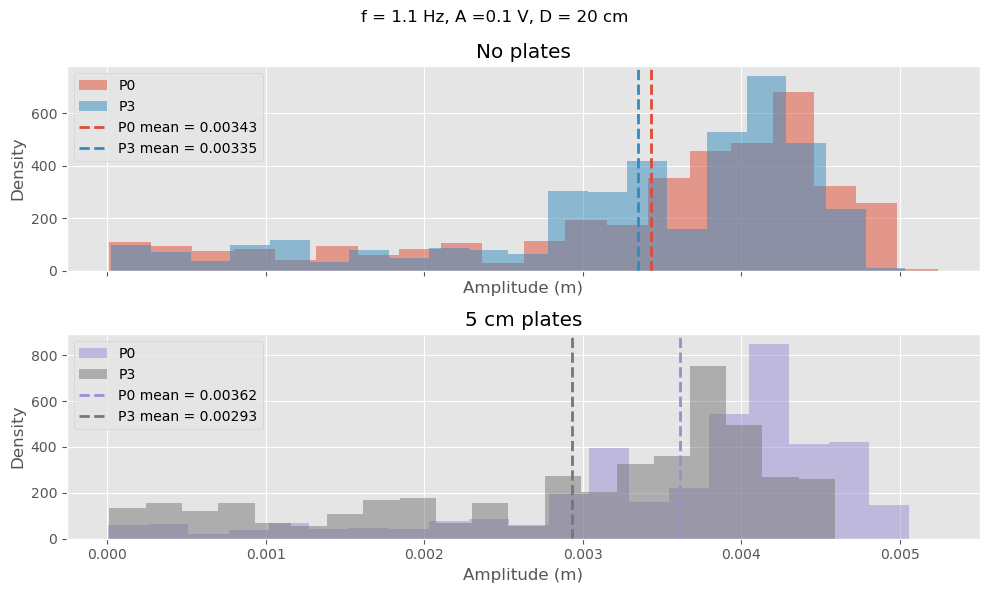

Frequency: 1.1, Voltage: 0.2


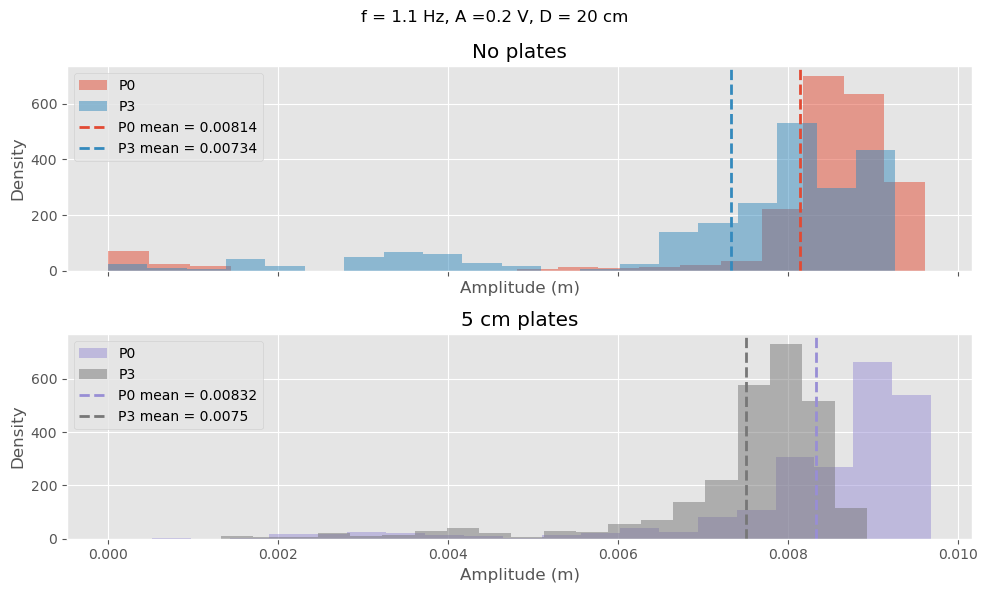

Frequency: 1.1, Voltage: 0.3


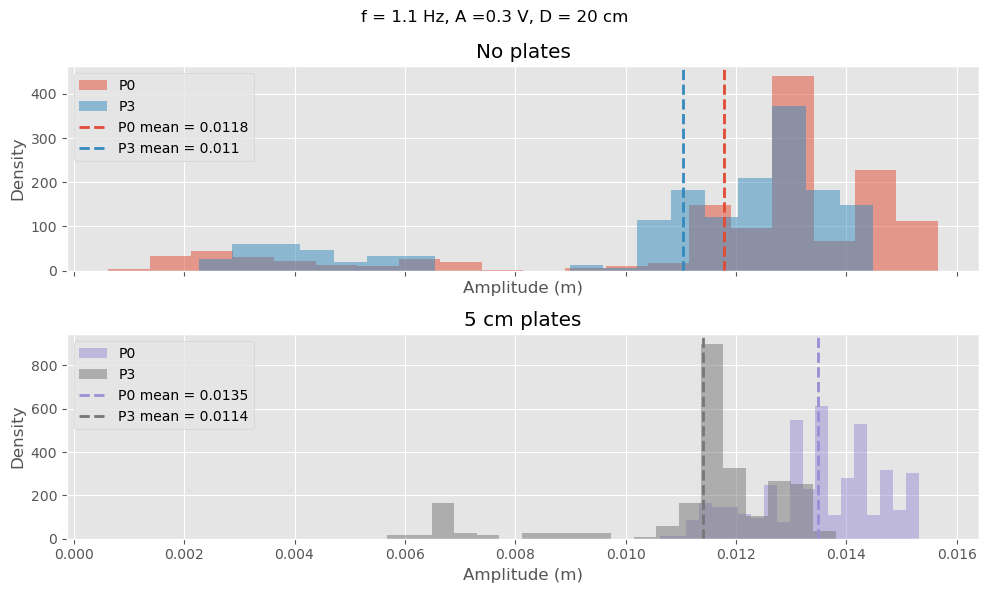

Frequency: 1.2, Voltage: 0.1


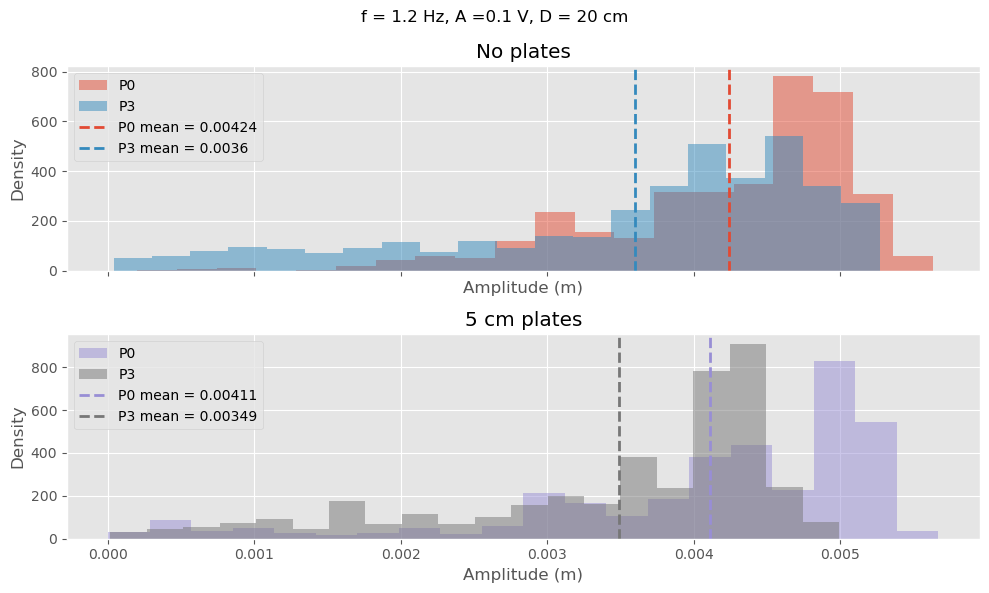

Frequency: 1.2, Voltage: 0.2


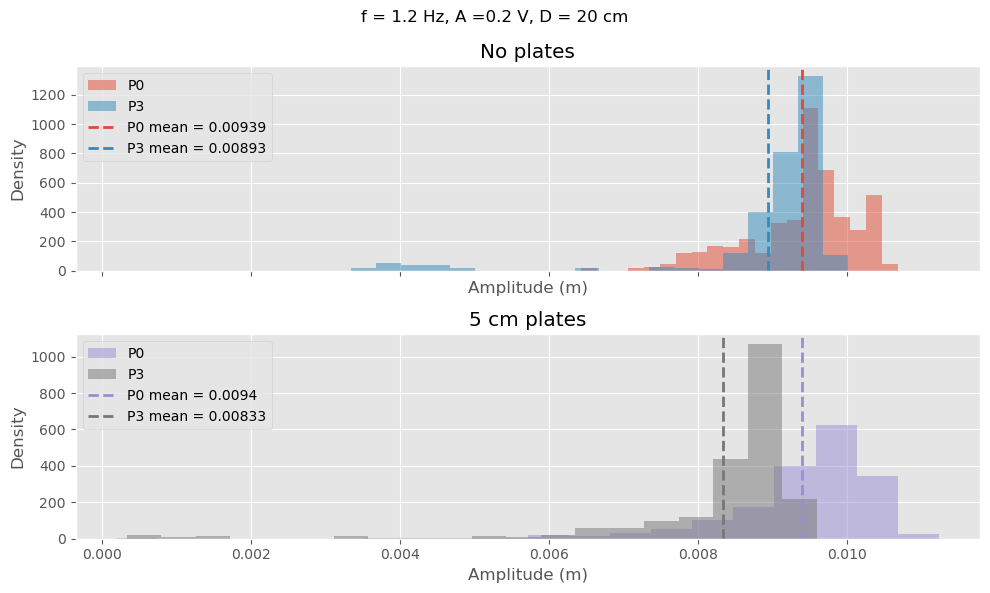

Frequency: 1.2, Voltage: 0.3


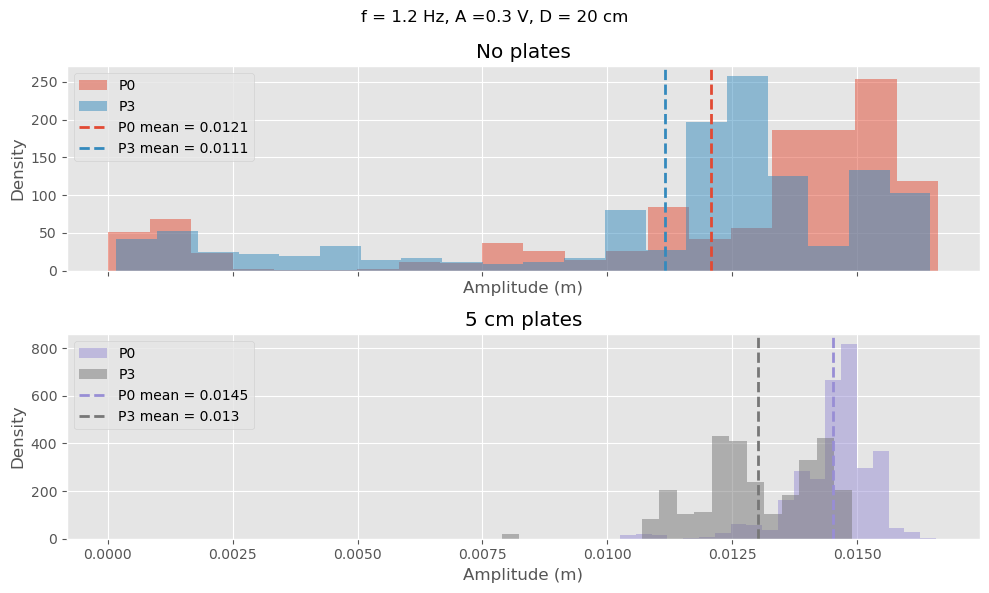

Frequency: 1.3, Voltage: 0.1


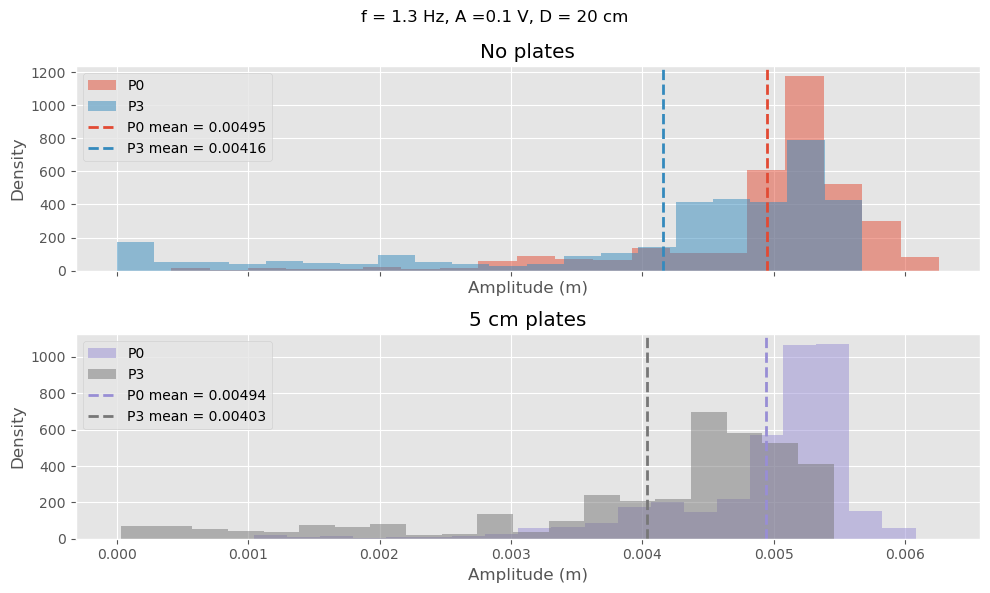

Frequency: 1.3, Voltage: 0.2


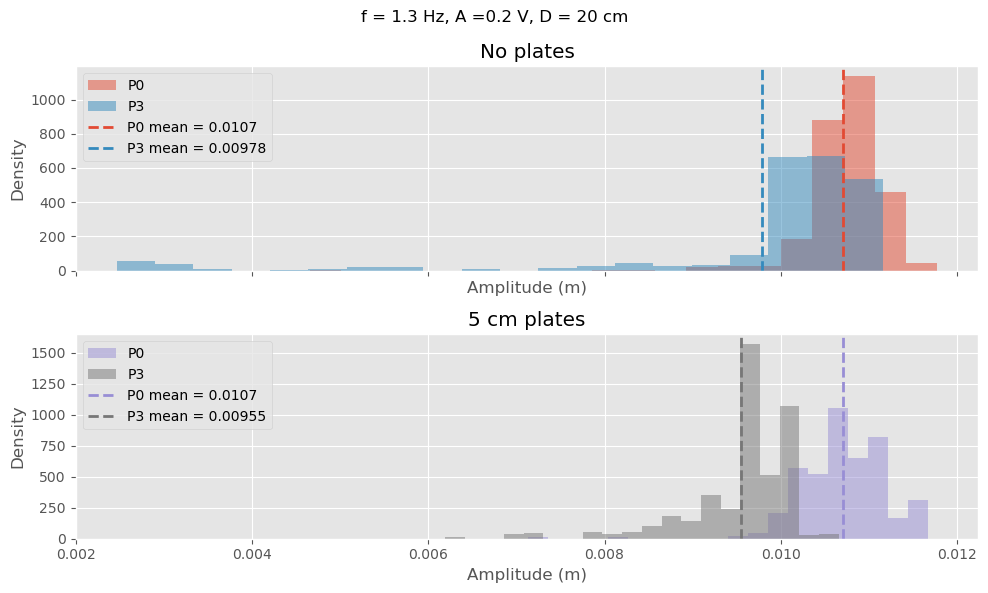

Frequency: 1.3, Voltage: 0.3


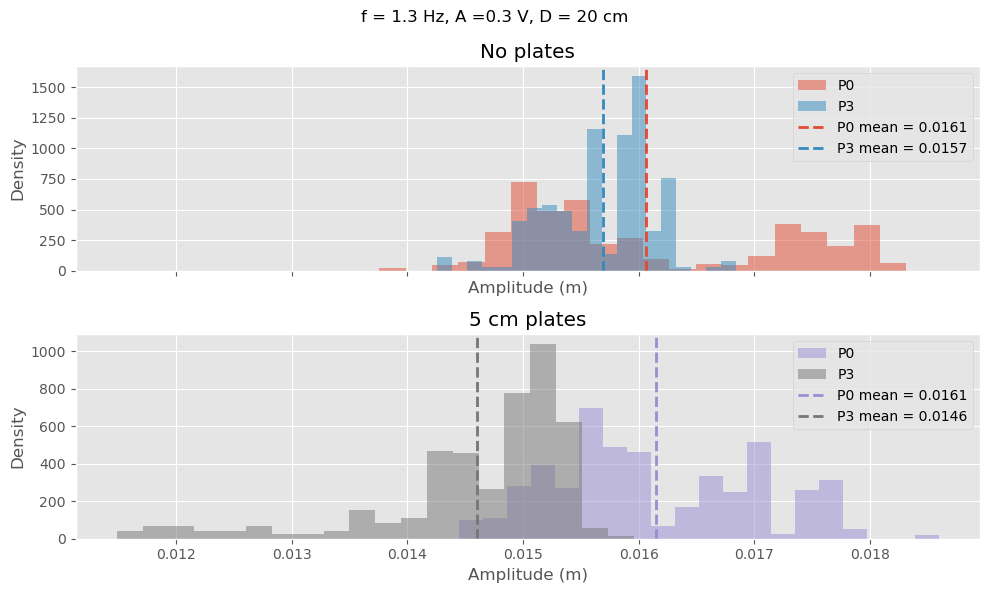

Frequency: 1.4, Voltage: 0.1


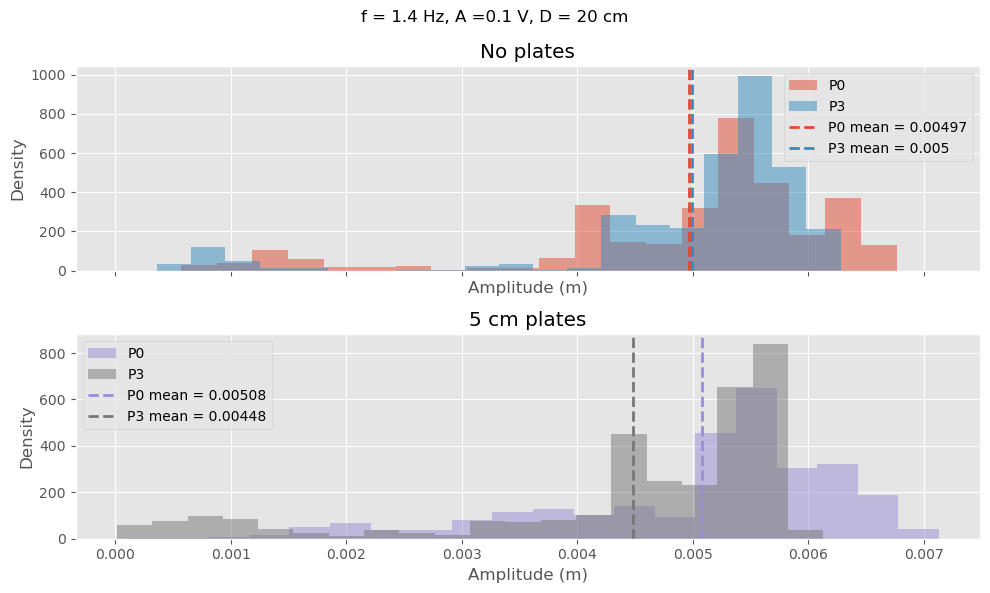

Frequency: 1.4, Voltage: 0.2


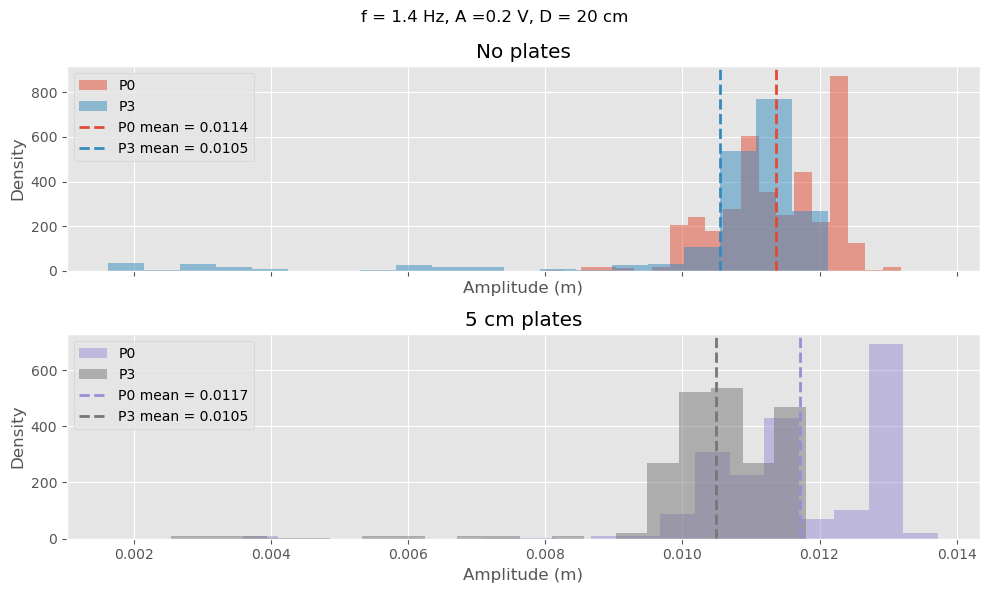

Frequency: 1.4, Voltage: 0.3


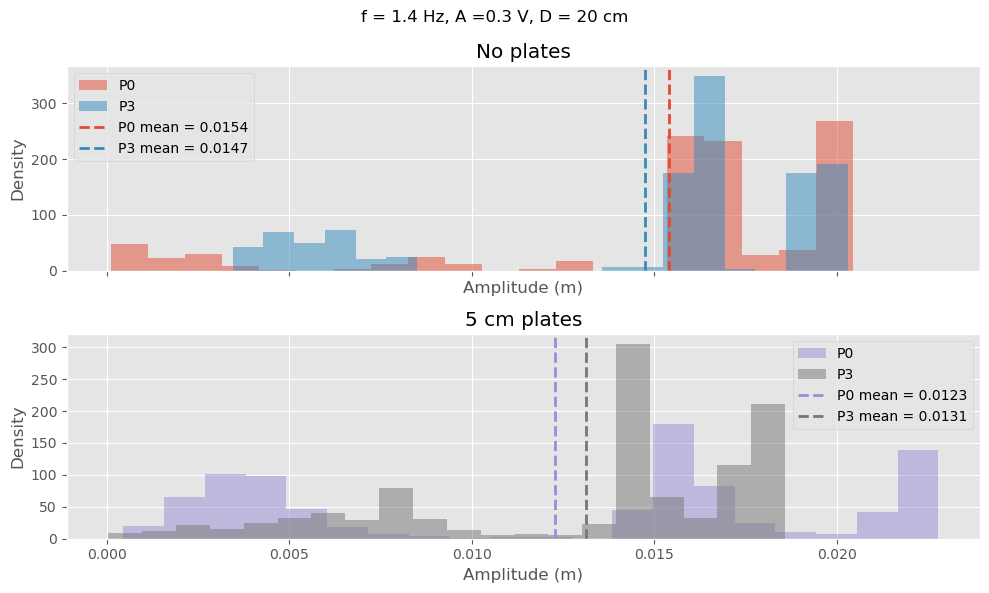

Frequency: 1.5, Voltage: 0.1


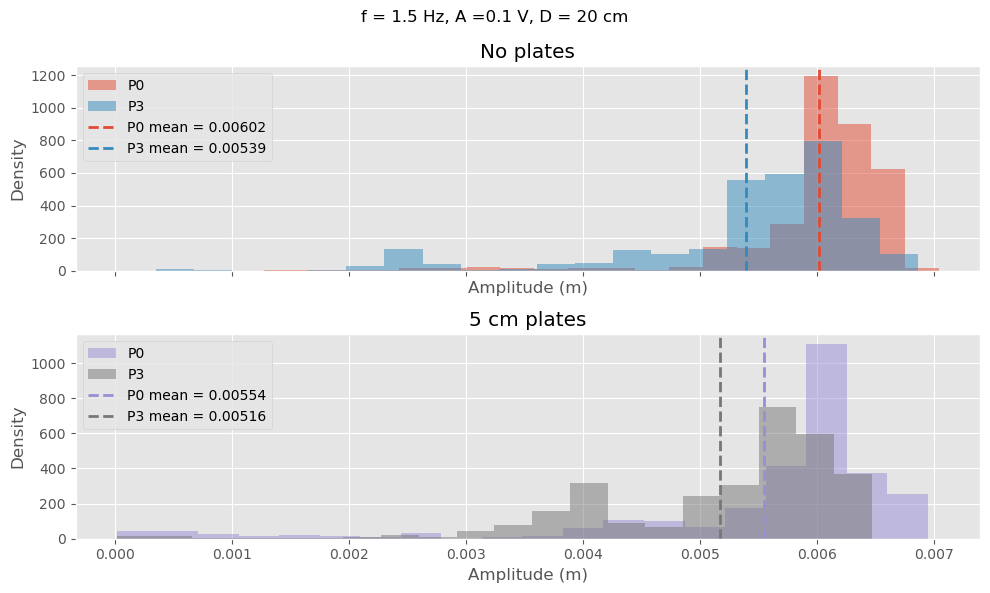

Frequency: 1.5, Voltage: 0.2


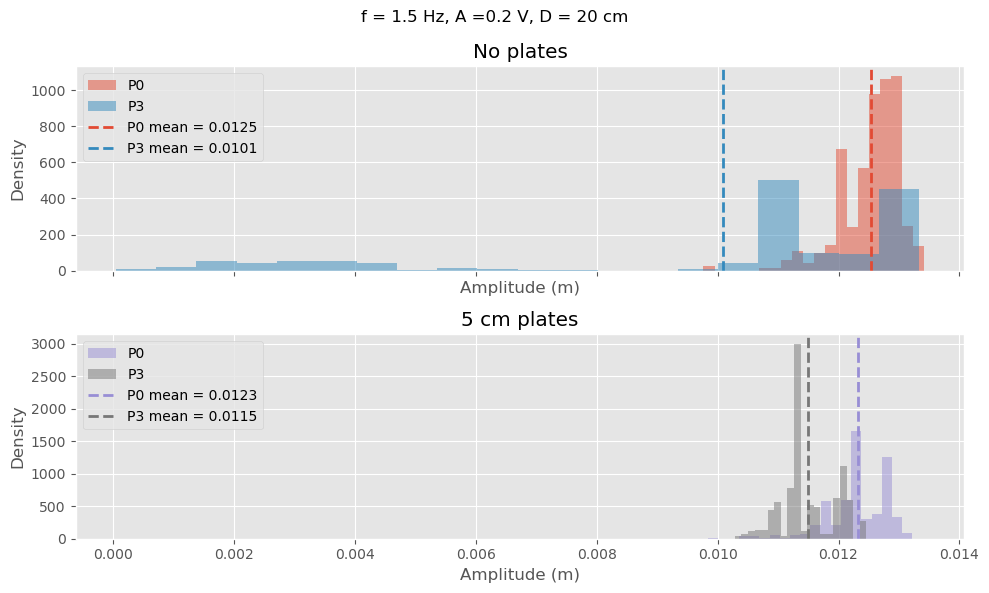

Frequency: 1.5, Voltage: 0.3


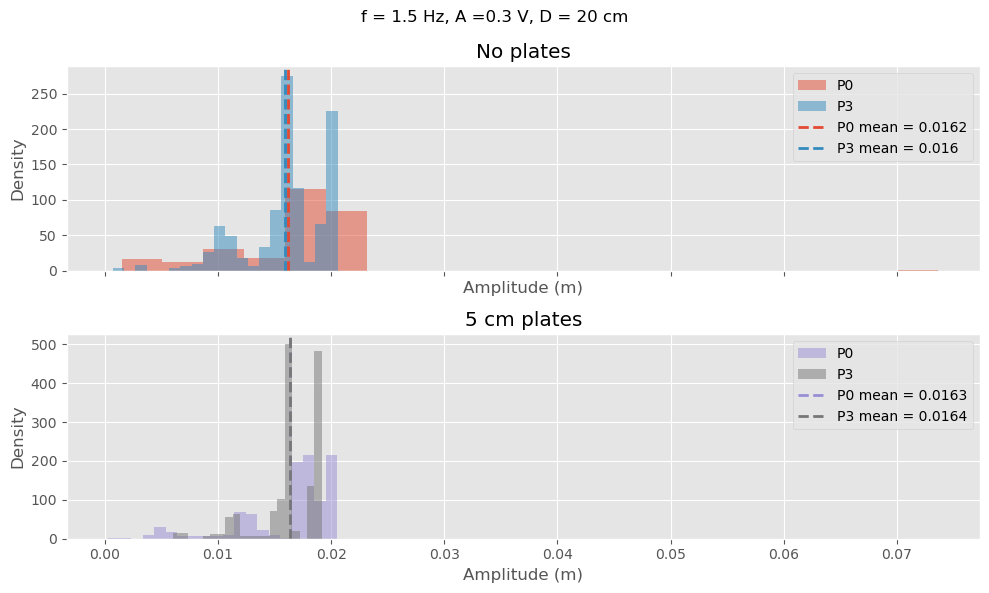

Frequency: 1.6, Voltage: 0.1


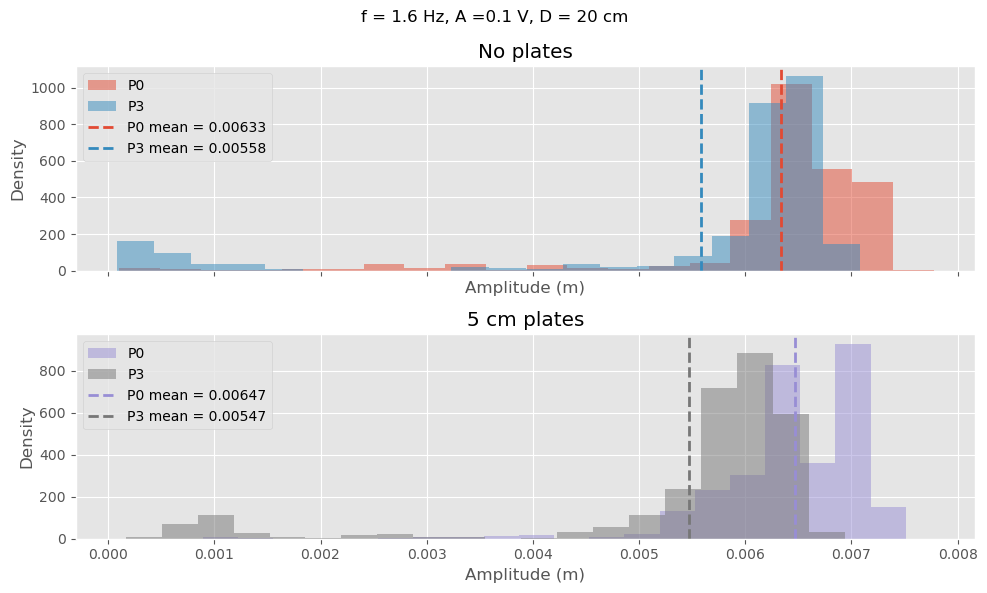

Frequency: 1.6, Voltage: 0.2


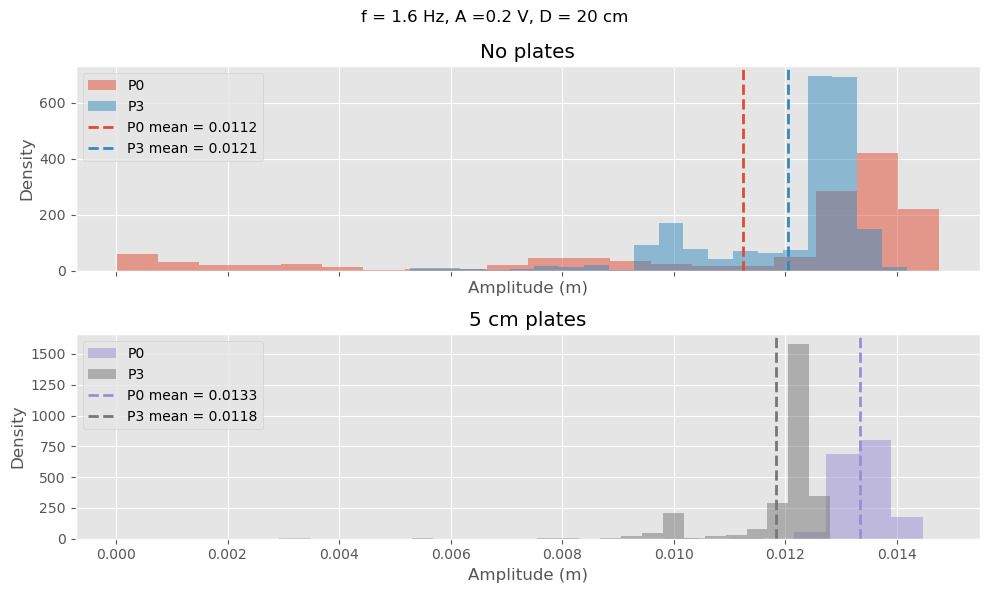

Frequency: 1.6, Voltage: 0.25


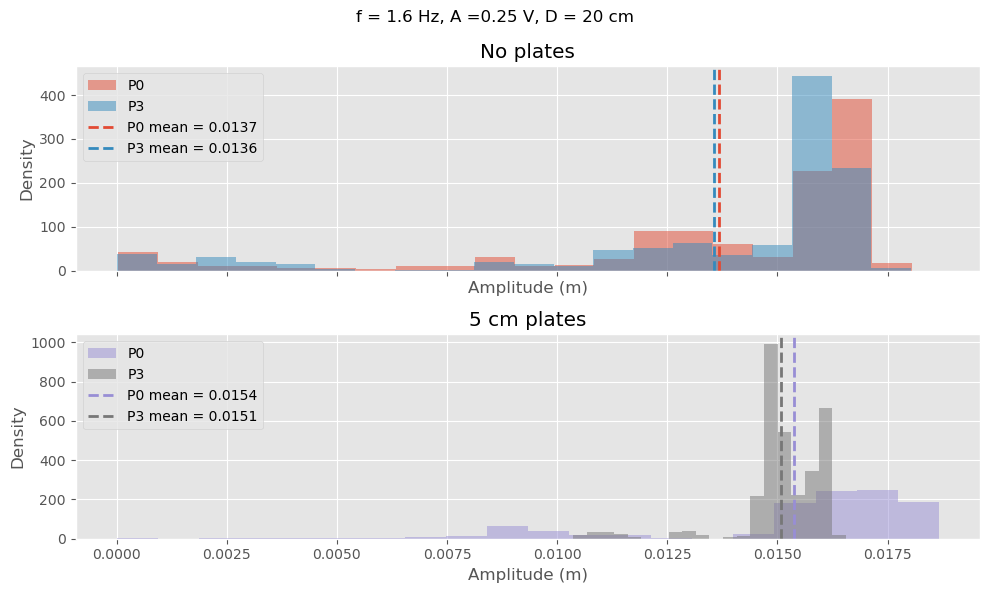

Frequency: 1.6, Voltage: 0.3


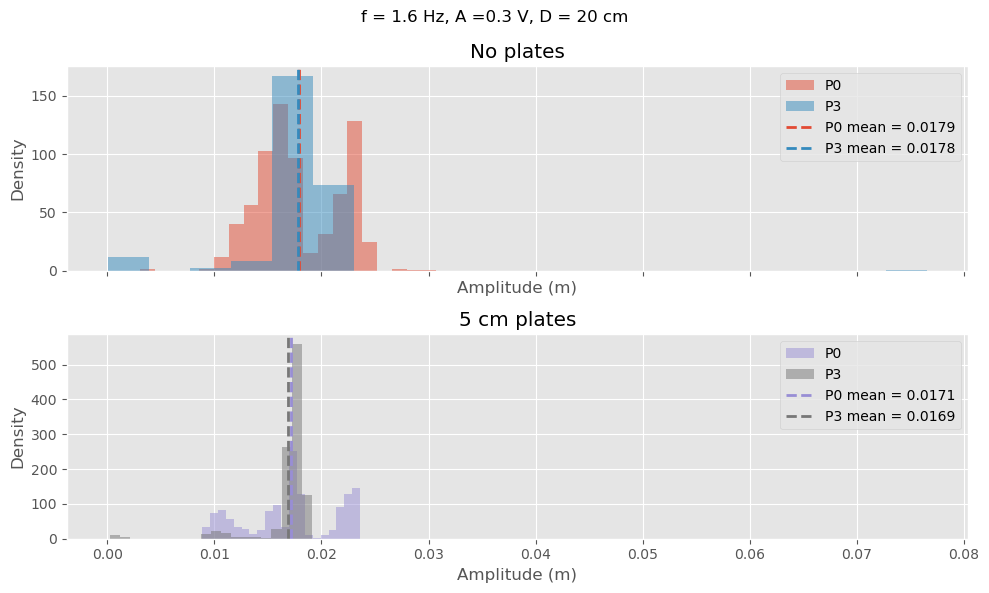

Frequency: 1.7, Voltage: 0.1


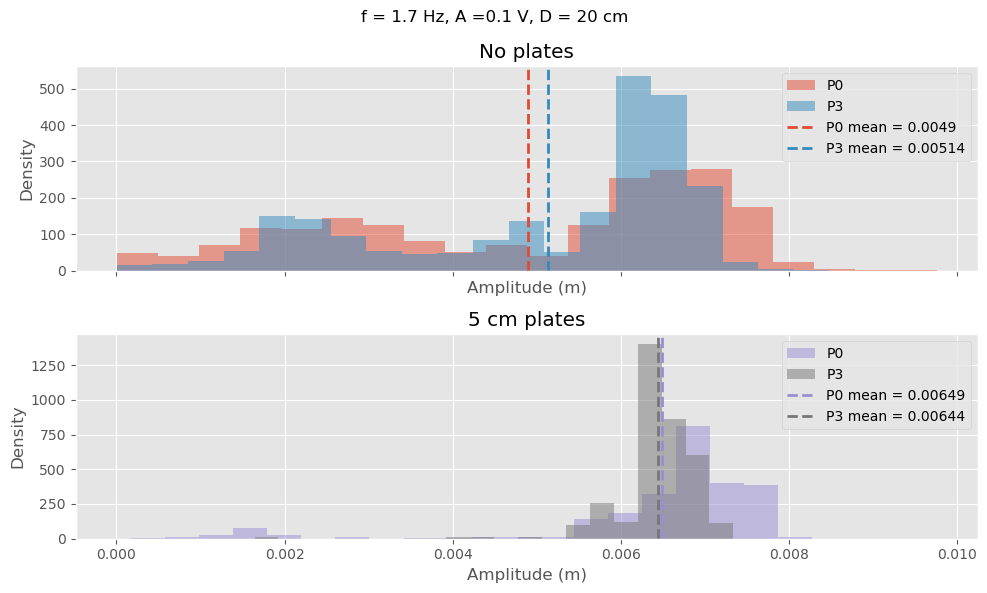

Frequency: 1.7, Voltage: 0.2


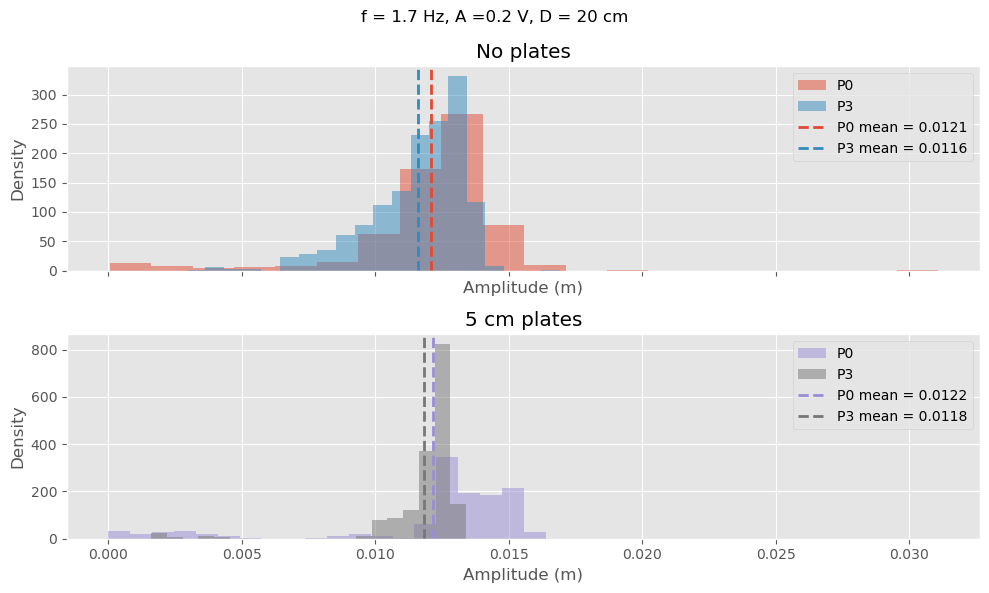

Frequency: 1.7, Voltage: 0.25


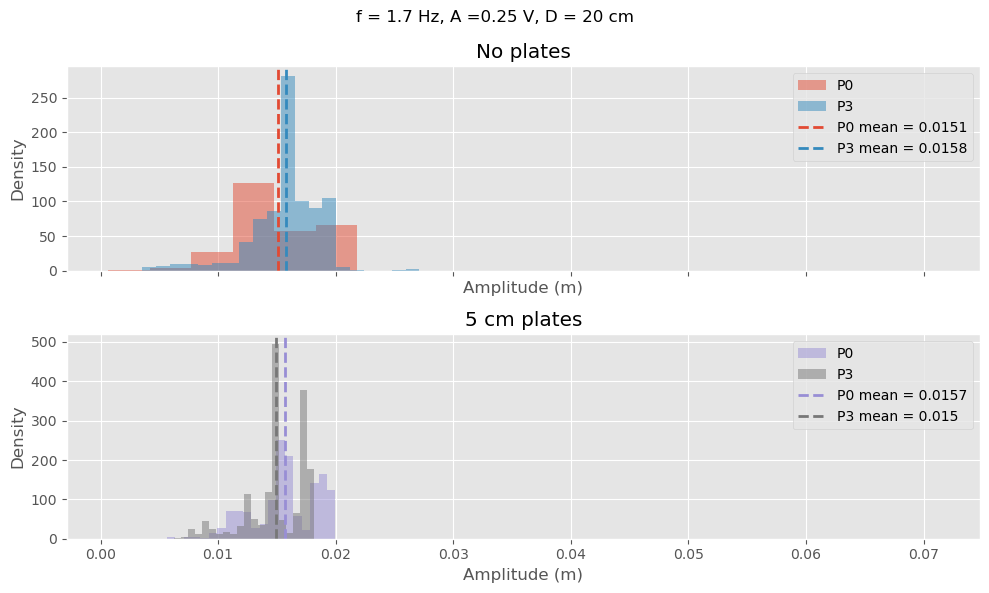

Frequency: 1.7, Voltage: 0.3


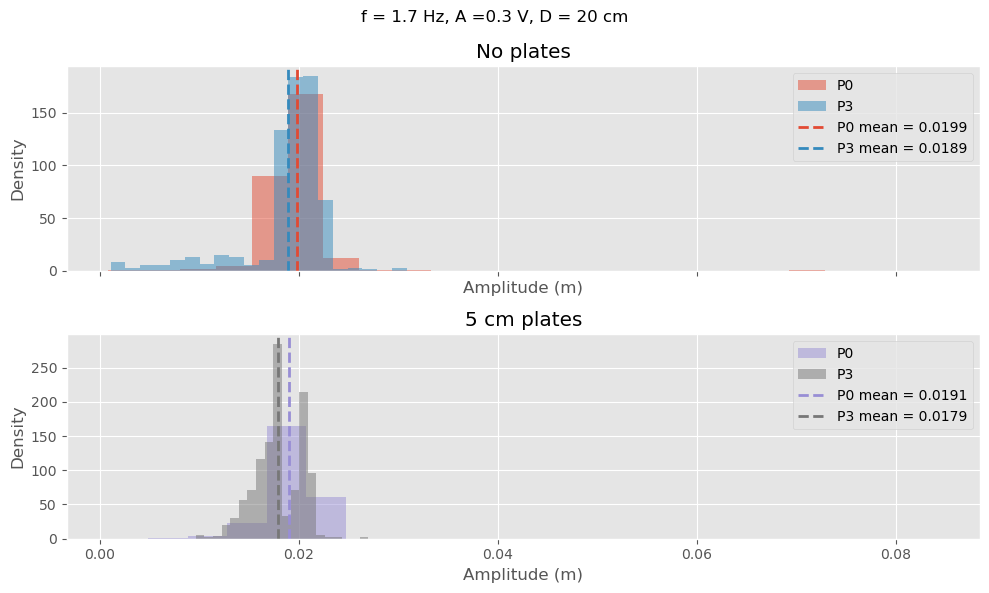

Frequency: 1.8, Voltage: 0.1


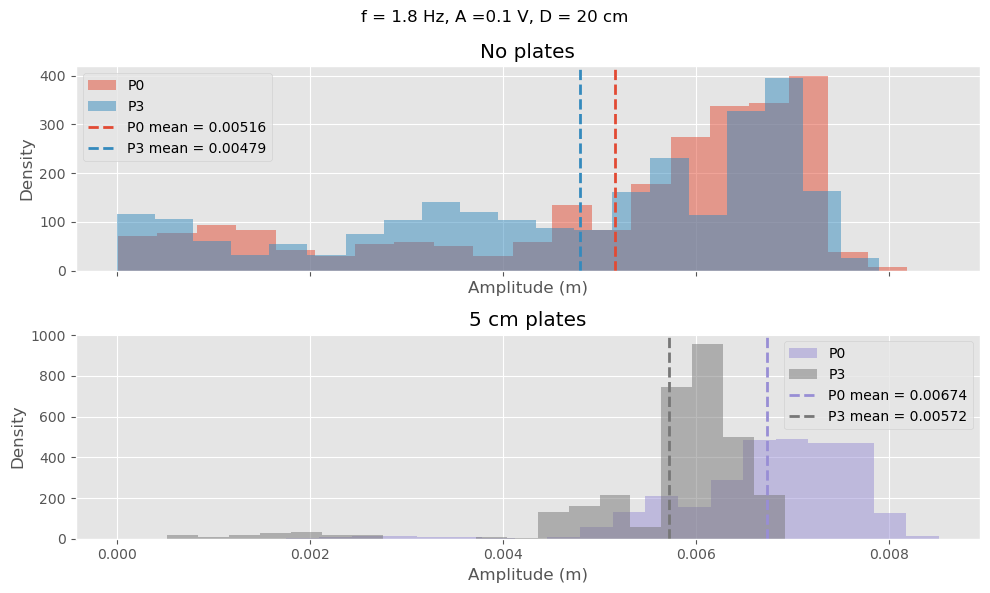

Frequency: 1.8, Voltage: 0.2


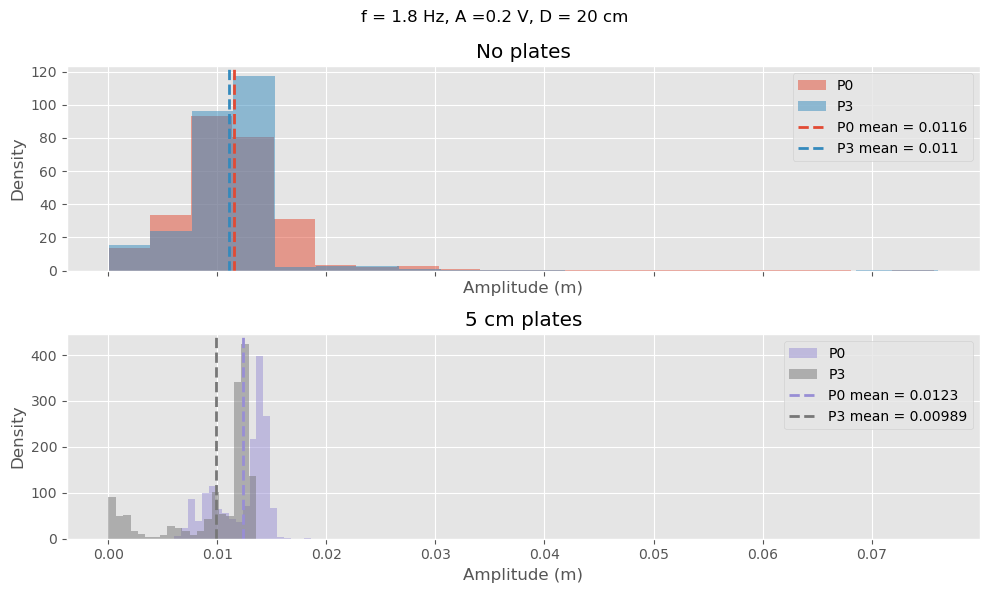

Frequency: 1.8, Voltage: 0.25


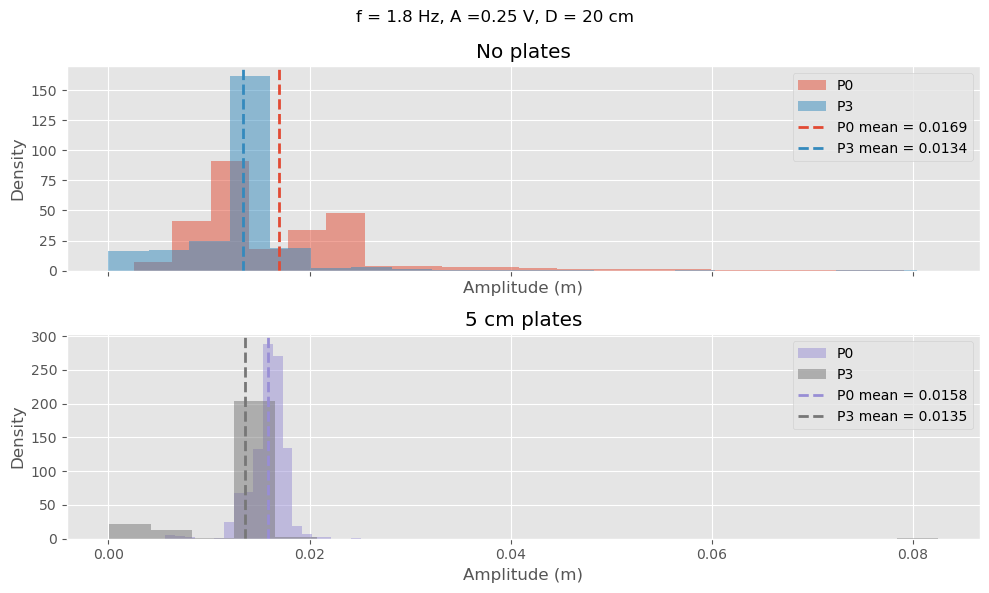

Frequency: 1.8, Voltage: 0.3


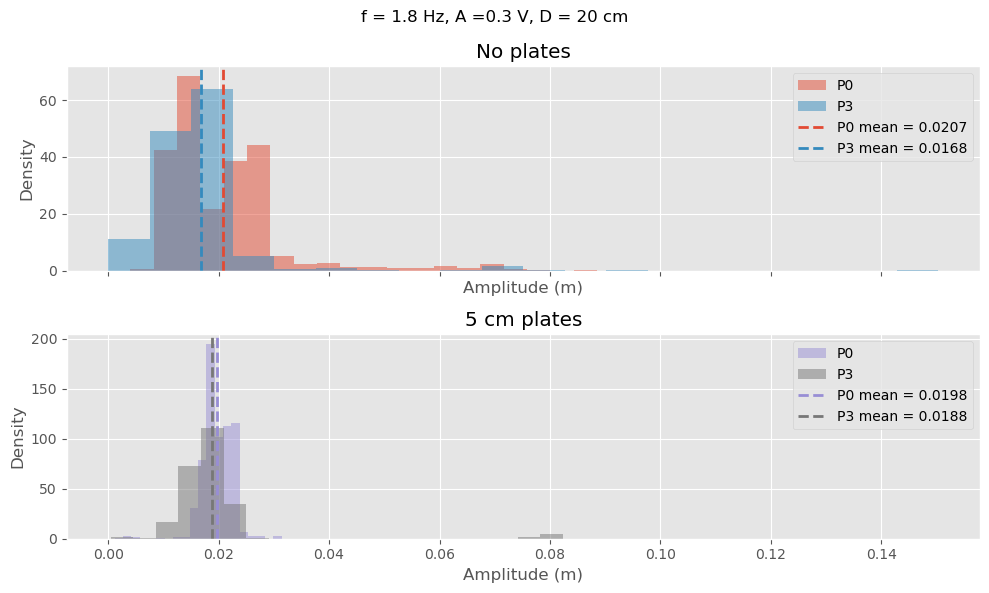

In [26]:
for i, f in enumerate(freqs):
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                # No plates
                eta_r1 = data[f][v][None]["R1"]
                eta_r2 = data[f][v][None]["R2"]
                eta_r3 = data[f][v][None]["R3"]

                P0_r1 = eta_r1["P_0"].dropna().values
                P0_r2 = eta_r2["P_0"].dropna().values
                P0_r3 = eta_r3["P_0"].dropna().values

                P3_r1 = eta_r1["P_3"].dropna().values
                P3_r2 = eta_r2["P_3"].dropna().values
                P3_r3 = eta_r3["P_3"].dropna().values

                amps_P0_r1 = get_amplitudes_from_run(P0_r1)
                amps_P0_r2 = get_amplitudes_from_run(P0_r2)
                amps_P0_r3 = get_amplitudes_from_run(P0_r3)

                amps_P0 = np.concatenate((amps_P0_r1, amps_P0_r2, amps_P0_r3))

                amps_P3_r1 = get_amplitudes_from_run(P3_r1)
                amps_P3_r2 = get_amplitudes_from_run(P3_r2)
                amps_P3_r3 = get_amplitudes_from_run(P3_r3)

                amps_P3 = np.concatenate((amps_P3_r1, amps_P3_r2, amps_P3_r3))

                mu_P0 = np.mean(amps_P0)
                mu_P3 = np.mean(amps_P3)
                std_P0 = np.std(amps_P0)
                std_P3 = np.std(amps_P3)

                # With plates
                eta_r1_p = data[f][v]["p005"]["R1"]
                eta_r2_p = data[f][v]["p005"]["R2"]
                eta_r3_p = data[f][v]["p005"]["R3"]

                P0_r1_p = eta_r1_p["P_0"].dropna().values
                P0_r2_p = eta_r2_p["P_0"].dropna().values
                P0_r3_p = eta_r3_p["P_0"].dropna().values

                P3_r1_p = eta_r1_p["P_3"].dropna().values
                P3_r2_p = eta_r2_p["P_3"].dropna().values
                P3_r3_p = eta_r3_p["P_3"].dropna().values

                amps_P0_r1_p = get_amplitudes_from_run(P0_r1_p)
                amps_P0_r2_p = get_amplitudes_from_run(P0_r2_p)
                amps_P0_r3_p = get_amplitudes_from_run(P0_r3_p)

                amps_P0_p = np.concatenate((amps_P0_r1_p, amps_P0_r2_p, amps_P0_r3_p))
                amps_P3_r1_p = get_amplitudes_from_run(P3_r1_p)
                amps_P3_r2_p = get_amplitudes_from_run(P3_r2_p)
                amps_P3_r3_p = get_amplitudes_from_run(P3_r3_p)

                amps_P3_p = np.concatenate((amps_P3_r1_p, amps_P3_r2_p, amps_P3_r3_p))

                mu_P0_p = np.mean(amps_P0_p)
                mu_P3_p = np.mean(amps_P3_p)
                std_P0_p = np.std(amps_P0_p)
                std_P3_p = np.std(amps_P3_p)

                fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

                # Histograms (normalized)
                ax[0].hist(amps_P0, bins=20, alpha=0.5, color='C0', label="P0", density=True)
                ax[0].hist(amps_P3, bins=20, alpha=0.5, color='C1', label="P3", density=True)

                ax[1].hist(amps_P0_p, bins=20, alpha=0.5, color='C2', label="P0", density=True)
                ax[1].hist(amps_P3_p, bins=20, alpha=0.5, color='C3', label="P3", density=True)

                # Mean lines
                ax[0].axvline(mu_P0, color='C0', linestyle='--', linewidth=2, label=f"P0 mean = {mu_P0:.3g}")
                ax[0].axvline(mu_P3, color='C1', linestyle='--', linewidth=2, label=f"P3 mean = {mu_P3:.3g}")
                ax[1].axvline(mu_P0_p, color='C2', linestyle='--', linewidth=2, label=f"P0 mean = {mu_P0_p:.3g}")
                ax[1].axvline(mu_P3_p, color='C3', linestyle='--', linewidth=2, label=f"P3 mean = {mu_P3_p:.3g}")

                
                ax[0].set_title('No plates')
                ax[1].set_title('5 cm plates')
                fig.suptitle(f"f = {f} Hz, A ={v} V, D = 20 cm")
                ax[0].set_xlabel("Amplitude (m)")
                ax[1].set_xlabel("Amplitude (m)")
                ax[0].set_ylabel("Density")
                ax[1].set_ylabel("Density")
                ax[0].legend()
                ax[1].legend()
                plt.tight_layout()
                plt.show()
                #plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Analysis/figs/amp_dist/freq_{f}_volt_{v}.png")